# Estimating phytoplankton absorption from TOA radiance (modeling & calibration)

## Preamble
**Purpose.** This notebook consumes the **processed dataset** from `00_preprocessing.ipynb` and implements the **Bayesian modeling and evaluation**: linear (indep.), multivariate linear with covariance (MVN), and a BART benchmark (indep.). It generates all **paper figures/tables** and SI diagnostics.

**Data intake.** Reads `data/processed/aph_toa_ready.parquet` and `data/processed/schema.json` produced by the preprocessing notebook. **No additional corrections or re-transforms are applied here.**

---

### What this notebook does

0. **Environment setup & presets**

1. **Data intake & quick survey (first section)**
   - Load processed dataset and schema.
   - **Seaborn pairplot** on **log-domain** predictors/responses (KDE diagonals) to visualize distributions and pairwise structure.
   - Sanity checks (row count \(=163\); required bands present).

2. **Models**
   - **Linear (independent)**: separate Gaussian residuals per band.
   - **Multivariate linear (MVN)**: shared mean; **full residual covariance** (LKJ prior).
   - **BART benchmark (independent)**: nonlinear mean per band; **not** pursued with full covariance (underperformed linear indep.; \(N=163\) is modest).

3. **Inference**
   - PyMC v5 **NUTS** (default 4 chains; 2,000 tune + 2,000 draws).
   - Save `InferenceData` to `idata/`.

4. **Evaluation & diagnostics**
   - **PSIS-LOO** comparison (ΔLOO, SE; optional stacking weights).
   - **LOO-PIT** (KDE + ECDF−uniform deviation).
   - **Posterior predictive checks**; **predictive coverage** (50/80/95%).
   - Optional SI robustness: **band ablation** / **noise inflation**.

5. **Manuscript outputs**
   - `figs/fig1_obs_vs_pred_mvn.pdf`
   - `figs/fig2_loo_pit_mvn.pdf`
   - `figs/fig3_coverage_mvn.pdf`
   - `results/table1_model_compare.tex`
   - SI diagnostics saved as `Fig. S*` / `Table S*`.

---

### Notes & scope

- Predictive (conditional) task; not an IOP inversion.
- Predictors are **log\(_{10}\)** corrected TOA radiances (SeaWiFS 412–670 nm).
- Responses are **log\(_{10}\)** \(a_\phi\) at **443, 555, 670 nm**.
- **No standardization** of predictors.

---

### Environment presets & exports

- Prints Python/PyMC/ArviZ/NumPy/Matplotlib versions on start.
- Figures exported as **vector PDFs** at PNAS column widths; tables as LaTeX.
- All artifacts written under `figs/`, `results/`, `idata/`.


In [ ]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

from itertools import combinations
from pathlib import Path

# ---------- DATA ----------
import pandas as pd
import numpy as np
import xarray as xr

# ---------- MODELING ----------

import pymc as pm
import pymc_bart as pmb
import pytensor.tensor as pt

# ---------- PLOTTING ----------

import matplotlib as mpl
import matplotlib.pyplot as pp
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import arviz as az
import seaborn as sb

# ---------- HOMEGROWN ----------

from scripts.model_utils import save_idata
from scripts.model_utils import find_influential_observations, posterior_coverage

from scripts.pnas_utils import set_pnas_style, fig_ax, save_pnas, pnas_figure
from scripts.plot_utils import  plot_regression_hdi, plot_3_way_ppc
from scripts.plot_utils import plot_ppc_pit_grid, compare_ppc, plot_ppc_pit

In [2]:
print('Package Versions: ', end='\n' + 50*'--' + '\n')
print(f'PyMC - {pm.__version__}')
print(f'PyMC-BART - {pmb.__version__}')
print(f'PanDaS - {pd.__version__}')
print(f'Arviz - {az.__version__}')
print(f'Seaborn - {sb.__version__}')

Package Versions: 
----------------------------------------------------------------------------------------------------
PyMC - 5.20.1
PyMC-BART - 0.9.0
PanDaS - 2.2.3
Arviz - 0.21.0
Seaborn - 0.13.2


In [3]:
# A bit of setup
ROOT = Path(".").resolve()
DIR = {
    "data": ROOT / "data/03_transformed",
    "idata": ROOT / "inferencedata",
    "figs": ROOT / "figs",
    "results": ROOT / "results",
}
for d in DIR.values():
    d.mkdir(parents=True, exist_ok=True)

set_pnas_style(base_font_size=9)

In [4]:
# SOME CONFIGS 

# Common constants
APH_BANDS = [443, 555, 670]
TOA_BANDS = [412, 443, 490, 510, 555, 670]
MODEL_TAGS = {
    "model1_linear_diag": "linear_diag",
    "model2_bart_diag":   "bart_diag",
    "model3_linear_full": "linear_fullcov",
}

PNAS_WIDTH_IN = {"one": 3.43, "two": 7.00}
# Colorblind-safe mapping (Okabe–Ito)
BAND_COLORS = {
    443: "#0072B2",  # blue
    555: "#009E73",  # green
    670: "#D55E00",  # vermillion
}
PPC_COLORS: list[str]= ['darkgray', 'k', 'C1']

legend_handles = [
    Line2D([0], [0], color=BAND_COLORS[443], lw=1.2, label="443 nm"),
    Line2D([0], [0], color=BAND_COLORS[555], lw=1.2, label="555 nm"),
    Line2D([0], [0], color=BAND_COLORS[670], lw=1.2, label="670 nm"),
]

In [5]:
# Last minute plot setting functions

def facet_height_for_pnas(ncols, width="two", aspect=1.0, min_height=1.0):
    target_w = PNAS_WIDTH_IN[width]
    return max(min_height, (target_w / max(1, ncols)) / aspect)

def save_model_dag(model, outpath, width="two", rankdir="LR"):
    W = 3.43 if width == "one" else 7.00  # inches
    g = pm.model_to_graphviz(model)
    g.graph_attr.update({
        "rankdir": rankdir,     # left→right often reads better
        "size": f"{W},{W*0.6}!",# width x height (force fit)
        "ranksep": "0.30",      # node layer spacing
        "nodesep": "0.25",      # sibling spacing
        "dpi": "300",
    })
    g.format = "pdf"
    stem = Path(outpath).with_suffix("")  # Graphviz adds .pdf
    g.render(filename=str(stem), cleanup=True)

In [6]:
# Load all saved InferenceData into a single dictionary

from scripts.model_utils import load_idata


# Map friendly names → file tags (tag.nc)
MODEL_TAGS = {
    "Linear (diag)":       "linear_diag",
    "BART (diag)":         "bart_diag",
    "Hier-Linear (diag)":  "hier_lin_diag",
    "Linear (full Σ)":     "linear_mvn",
}

# Load
idatas = {name: load_idata(tag, DIR["idata"]) for name, tag in MODEL_TAGS.items()}

# (Optional) Normalize a non-ASCII coord name to ASCII once, if needed
def normalize_lambda_coord(idata, old="λ_aφ", new="lambda_aph"):
    # Rename in any group that contains this dim/coord
    for grp in ("posterior","prior","posterior_predictive","prior_predictive",
                "observed_data","constant_data","sample_stats","log_likelihood"):
        ds = getattr(idata, grp, None)
        if ds is not None and (old in ds.dims or old in ds.coords):
            setattr(idata, grp, ds.rename({old: new}))
    return idata

# Uncomment if your saved files use 'λ_aφ'
# idatas = {k: normalize_lambda_coord(v) for k, v in idatas.items()}

# Optional: unpack for convenience
idata_lin  = idatas["Linear (diag)"]
idata_bart = idatas["BART (diag)"]
idata_hier = idatas["Hier-Linear (diag)"]
idata_mvn  = idatas["Linear (full Σ)"]

print("Loaded models:", ", ".join(idatas.keys()))


Loaded models: Linear (diag), BART (diag), Hier-Linear (diag), Linear (full Σ)


---
## Quick data survey

- Load the processed dataset from `00_preprocessing.ipynb`.
- Create a **seaborn pairplot** (KDE diagonals) on the **log-domain** variables to visualize distributions and pairwise relationships before fitting models.

### Load and prep data

In [7]:
df_log = pd.read_parquet(DIR['data'] / 'df_log.pqt') # Contains TOA radiance and Phytoplankton Absorption 
df_log.head()

,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,log_Rrc_555,log_Rrc_670,log_aph443,log_aph555,log_aph670
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,NaN,NaN,NaN
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,NaN,NaN,NaN
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,-1.511731,-2.414539,-1.982967
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-1.641494,-2.508638,-2.029188
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,NaN,NaN,NaN


In [8]:
X = df_log.dropna().filter(regex='Rrc')
Y = df_log.dropna().filter(regex='aph')

### Visualize data

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


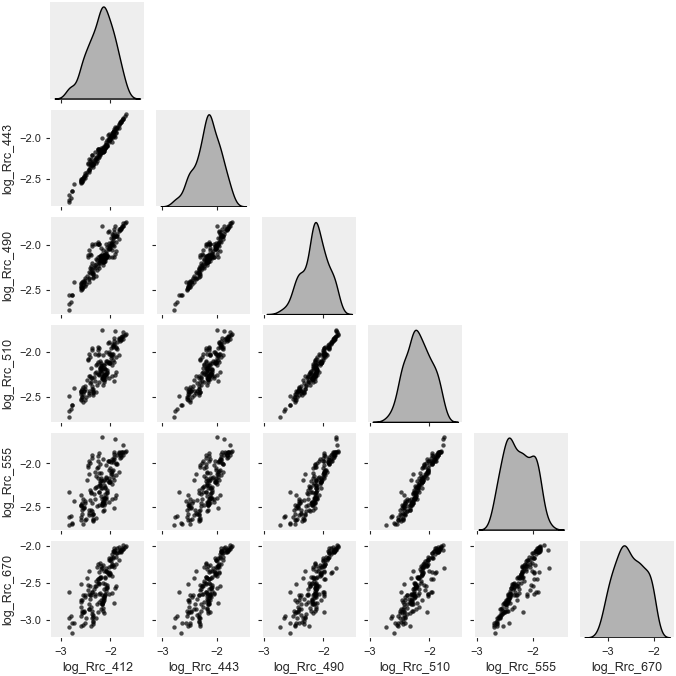

In [ ]:
# Example: predictors-only corner plot (6 vars)
ncols = 6
height = facet_height_for_pnas(ncols, width="two", aspect=1.0, min_height=1.0)
g = sb.pairplot(X, corner=True, diag_kind="kde",
                 plot_kws=dict(s=10, alpha=0.7, linewidth=0),
                 height=height, aspect=1.0)
save_pnas(g.fig, DIR["figs"]/ "si" / "figS_pairplot_predictors.pdf")


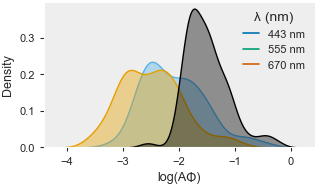

In [489]:
fig, ax = fig_ax(width="one", aspect=0.62)
ax = sb.kdeplot(Y, fill=True, alpha=0.4, legend=False, ax=ax)
ax.legend(handles=legend_handles, title='λ (nm)')
ax.legend(handles=legend_handles, title='λ (nm)', frameon=False)
ax.set_xlabel('log(AΦ)')
ax.set_ylabel('Density')
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_kde_aph_overlaid.pdf")

# Modelling

## Bayesian workflow steps applied to all models

This section documents the **repeatable flow** I apply to each model so results are comparable and reproducible. If a step fails its checks, the use should stop and see if there is something to fix before proceeding. But nothing here is dogmatic; failures are suggestive of potential issues, and the user should exercise judgment (this part becomes easier with experience).

1. **Model specification.**  
   I define the likelihood and priors in the **log-domain** with consistent variable names (observed node: `likelihood`). For diagonal-$\Sigma$ models, residuals are independent across bands; for MVN, I parameterize a full covariance via an LKJ prior on correlations.

2. **Model DAG visualization.**  
   I render the computational graph to sanity-check dependencies and shapes. *Note:* for BART, Graphviz may show an arrow from $y$ to $\mu$—that reflects **inference dependencies** (residual updates), not the **generative DAG**.

3. **Prior predictive check (gate).**  
   I draw from the **prior predictive** and visualize summaries (cumulative/KDE). I verify that simulated $y$ spans plausible ranges for $\log_{10} a_\phi$ across bands.  
   **Decision rule:** if priors are too tight/too diffuse or clearly implausible, I **revise the priors or mean structure** and re-run the prior predictive **before** any posterior sampling.

4. **Posterior sampling (NUTS).**  
   I run NUTS with multiple chains, fixed seeds, and adequate tuning (default 2k tune + 2k draws unless otherwise noted). I store `log_likelihood`, `posterior_predictive`, and (when helpful) deterministic nodes like $\mu$.

5. **Sampling diagnostics (must pass).**  
   I evaluate:
   - **Summary:** $\hat{R}<1.01$ for all reported parameters; **bulk/tail ESS** comfortably into the **hundreds** (relative to total draws), and **MCSE** small relative to posterior SD.  
   - **Trace plots:** “fuzzy caterpillars” with good **chain overlap** and no stickiness or multimodal drift; no persistent trends across iterations.  
   - **Energy/BFMI:** **no divergences**; **BFMI ≥ 0.3** and **energy overlap** across chains; **max tree depth** not frequently saturated; step size stable.  
   If any of these fail, I adjust tuning, reparameterize (e.g., uncentered), or revisit priors.

6. **Posterior predictive checks & log-likelihood.**  
   I compute **posterior predictive** draws and visualize PPCs (by band and aggregated). I also compute and store **pointwise `log_likelihood`** for downstream PSIS-LOO, Pareto-$k$, and PIT.

7. **Fit, generalizability, and calibration diagnostics.**  
   I assess:
   - **PSIS-LOO model comparison:** report **ΔELPD** with **SE**, plus (optionally) stacking weights. I flag **influential observations** via **Pareto-$k$** (good < 0.5; caution 0.5–0.7; high > 0.7).  
   - **Uncertainty calibration:** **predictive coverage** at **50/80/95%** per band; **LOO-PIT** to detect miscalibration (U-shaped/∩-shaped/skewed).  
   - **Residual structure:** where relevant, inspect **posterior residual correlations** to motivate diagonal vs full $\Sigma$.  

**Presentation note.** For the main text, I show **LOO-PIT only for the final MVN model**; PIT for other models is included in **SI only if** ΔELPD is close or PPC/coverage indicate miscalibration worth documenting. All PPCs, coverage CSVs, Pareto-$k$ CSVs, and compare tables are exported with **standardized filenames**.


## Preparation

Note that I do not use, nor recommend, pre-processing steps that are parameterized using the training data (the data used for model development). 
The point of Bayesian Modeling is to approximate the data generation process, and not the data. However such pre-processing steps - e.g. standardization,
or dimensional reduction via PCA/EOF incidentally render the model dependent on training data. I therefore limit any transformation to endogenous operation; log-transformation of inputs and outputs in the present case.

In [12]:
x_idx, x_names = X.columns.factorize()
y_idx, y_names = Y.columns.factorize()
λ =   [li.split('Rrc_')[-1] for li in x_names]
λ_aph =   [li.split('aph')[-1] for li in y_names]
coords= {
    'obs_idx': X.index,
    'λ_toa': λ, 
    'λ_aφ' : λ_aph
}

## A — Models with (diagonal Σ) residual structure  to isolate mean-function effects

###  Model 1 — Linear mean with diagonal $\Sigma$ (baseline)

**Why this model.**  
Simplest parametric baseline. Keeps residuals **independent across bands** (diagonal $\Sigma$) to isolate the effect of the **mean function**. Mild Gaussian priors help with the known **collinearity** among TOA radiances without standardizing predictors.

**Model (log-domain).**  
For $k\in\{443,555,670\}$ and $j\in\{1,\dots,6\}$:
$$
y_{i,k}\mid \mu_{i,k},\sigma_k \sim \mathcal{N}(\mu_{i,k},\sigma_k^2),\qquad
\mu_{i,k}=\alpha_k+\sum_{j=1}^6 \beta_{j,k}\,x_{i,j},
$$
$$
\alpha_k\sim\mathcal{N}(0,1),\quad \beta_{j,k}\sim\mathcal{N}(0,1),\quad
\sigma_k\sim\mathrm{Exponential}(1).
$$
Observed node is named **`likelihood`**.

#### 1) Model Code

In [13]:
# simple linear model first as benchmark
with pm.Model(coords=coords) as m_lin: 
    X_data = pm.Data(
        'log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data(
        'log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    α = pm.Normal('α', 0, 1, dims='λ_aφ')
    β = pm.Normal('β', 0, 1, dims=['λ_toa', 'λ_aφ'])
    μ = α + X_data @ β
    σ = pm.Exponential('σ', 1, dims='λ_aφ')
    likelihood = pm.Normal(
        'likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])


#### 2) Model DAG visualization.**  
- Sanity-check parent/child relationships and tensor shapes.  

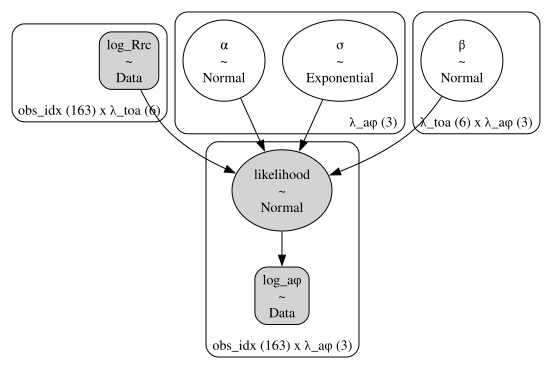

In [467]:
g = m_lin.to_graphviz()
g

In [488]:
save_model_dag(m_lin, DIR["figs"]/ "si" / "figS_dag_linear_diag.pdf", width="two")

#### 3) Prior predictive check  
- Visualize prior predictive vs. observed ranges (e.g., cumulative or KDE).  
- Decision rule: if implausible/tight/diffuse → adjust priors/structure **before** sampling.  
**Result notes:** [does prior predictive bracket plausible $\log_{10}a_\phi$? → ______]  
**Artifact:** [prior PPC fig path → ______]

In [ ]:
with m_lin:
    idata_lin = pm.sample_prior_predictive()

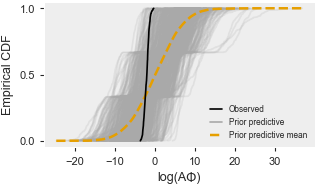

In [490]:
fig, ax = fig_ax(width="one", aspect=0.62)
az.plot_ppc(
    idata_lin, group='prior', kind='cumulative', 
    colors=PPC_COLORS, observed=True, ax=ax)

ax.set_xlabel('log(AΦ)')
ax.set_ylabel('Empirical CDF')
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_prior_ppc_linear_diag.pdf")

#### 4) Posterior sampling (NUTS).**  
- Settings: [chains = 4, tune = 1000 , draws = 2000/chain, target_accept = 0.80 (default)].  
- Stored: `log_likelihood`, `posterior_predictive`, [and `μ` if available].  
**Result notes:** [No warnings/divergences]


In [280]:
with m_lin:
    idata_lin.extend(pm.sample(chains=4, draws=2000))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, σ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 134 seconds.


#### 5) Sampling diagnostics.**  

* Summary statistics, examining
    - $\hat{R}$ to assess convergence of independent MCMC chains
        * should be about 1.0 - 1.01
    - Effective Sample Size (ESS) to verify sufficient independent samples were collected in key areas of the posterior. 
        * should be in the high 100s to 1000s
    - check for r_mcse to confirm posterior sampling was adequate
        * should be much less than 0.05

* Evaluate energy plot checking that:
    * Marginal Energy and Energy transition distribution KDEs overlap well
    * All chains show BFMI > 0.3

* Visualize trace plots checking that:
    * all traces look well mixed (fuzzy caterpillar appearance)
    * satisfactory overlap of parameter marginal posteriors
    * make note which parameter's (if any) marginal posterior overlap '0' 
        - ths can also be confirmed via summary table (hdi_lo and hdi_hi on either side of 0)

In [499]:
summ = az.summary(idata_lin, var_names=["α","β","σ"], round_to=None)
summ

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α[443],-2.278,0.160,-2.573,-1.967,0.002,0.002,10292.0,6466.0,1.0
α[555],-3.122,0.266,-3.581,-2.577,0.003,0.004,11149.0,5252.0,1.0
α[670],-3.884,0.201,-4.243,-3.496,0.002,0.002,10467.0,5830.0,1.0
"β[412, 443]",0.993,0.508,0.044,1.964,0.006,0.006,6652.0,5582.0,1.0
"β[412, 555]",-0.074,0.586,-1.194,1.021,0.007,0.007,6550.0,4554.0,1.0
"β[412, 670]",0.333,0.546,-0.670,1.353,0.007,0.006,6268.0,5709.0,1.0
"β[443, 443]",-1.793,0.764,-3.255,-0.383,0.009,0.009,6992.0,5476.0,1.0
"β[443, 555]",-1.459,0.801,-2.979,0.039,0.009,0.010,7642.0,5319.0,1.0
"β[443, 670]",-1.634,0.782,-3.131,-0.219,0.010,0.009,6454.0,5191.0,1.0
"β[490, 443]",-2.270,0.695,-3.527,-0.905,0.008,0.007,7428.0,6074.0,1.0


In [501]:
summ["rMCSE_mean"] = summ["mcse_mean"] / summ["sd"]
summ["rMCSE_sd"]   = summ["mcse_sd"]   / summ["sd"]
summ[["rMCSE_mean","rMCSE_sd","ess_bulk","ess_tail","r_hat"]].describe()

,rMCSE_mean,rMCSE_sd,ess_bulk,ess_tail,r_hat
count,24.000000,24.000000,24.000000,24.000000,24.0
mean,0.010317,0.009966,7512.833333,5614.583333,1.0
std,0.004054,0.004035,1471.031837,421.178772,0.0
min,0.000000,0.000000,6114.000000,4554.000000,1.0
25%,0.011096,0.010250,6586.750000,5300.750000,1.0
50%,0.011682,0.011144,6869.500000,5645.500000,1.0
75%,0.012346,0.011845,7936.750000,5933.750000,1.0
max,0.012876,0.015038,11149.000000,6466.000000,1.0


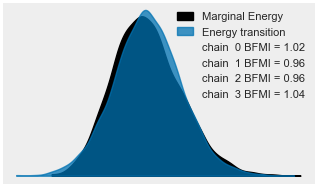

In [502]:
fig, ax = fig_ax()
az.plot_energy(idata_lin, ax=ax)
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_energy_linear_diag.pdf")

In [515]:
# Trace (compact) for a small var set — SI only
axs = az.plot_trace(
    idata_lin, compact=True, kind="rank_vlines",
    figsize=(7.0, 4.5))
axs[0, 0].legend(handles=legend_handles)
axs[2, 0].legend(handles=legend_handles)


pp.savefig(DIR["figs"]/"si"/"figS_m1_trace.pdf"); pp.close()

#### 6) Estimating model performance on: 

* In-sample data
    - Compute Posterior predictive checks & log-likelihood,
    - Can the model generate data similar to that seen during training

* Out-of-sample (future) data
    - Compute Pareto Smooth Importance Sampling (PSIS) Leave-One-Out (LOO) cross validation
    - Assess Pareto-k to detect possible presence of overly influential data
    - Compute & Plot Predictive Coverage
    - Assess calibration of uncertainties using LOO - Probability Integral Transform (PIT)

In [ ]:
with m_lin:
    idata_lin.extend(pm.sample_posterior_predictive(idata_lin))

Sampling: [likelihood]


Output()

In [ ]:
with m_lin:
    try:
        _ = pm.compute_log_likelihood(
            idata_lin, extend_inferencedata=True)
    except ValueError:
        pass

Output()

In [12]:
idata_lin

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

(<Figure size 700.787x385.433 with 3 Axes>,
 array([<Axes: title={'center': '$\\lambda = 443\\,\\mathrm{nm}$'}, xlabel='$\\log_{10}\\,a_{\\phi}$'>,
        <Axes: title={'center': '$\\lambda = 555\\,\\mathrm{nm}$'}, xlabel='$\\log_{10}\\,a_{\\phi}$'>,
        <Axes: title={'center': '$\\lambda = 670\\,\\mathrm{nm}$'}, xlabel='$\\log_{10}\\,a_{\\phi}$'>],
       dtype=object))

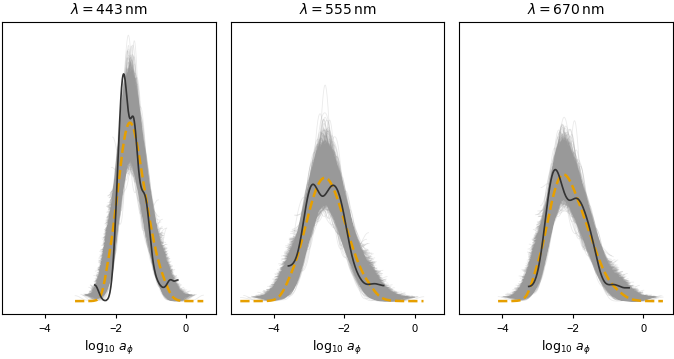

In [ ]:
# Cell 1 — 3-way PPC (KDE) for Models 1–3 (SI)
axs=plot_3_way_ppc(
    idata=idata_lin, var="likelihood",
    out=DIR["figs"] / "si" / f"figS_m1_ppc.pdf"
    )


(<Figure size 700.787x434.488 with 2 Axes>,
 array([<Axes: title={'center': 'Prior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(443\\,\\mathrm{nm})$'>,
        <Axes: title={'center': 'Posterior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(443\\,\\mathrm{nm})$'>],
       dtype=object))

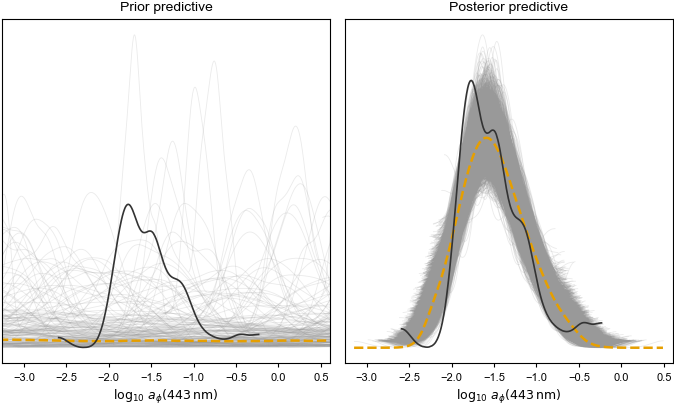

In [ ]:
# SI Figure: Prior vs Posterior PPC (band 443); falls back to posterior-only if no prior saved
band = 443
f, axs=compare_ppc(
    idata_lin, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m1_compare_ppc_{band}.pdf"
)

(<Figure size 700.787x434.488 with 2 Axes>,
 array([<Axes: title={'center': 'Prior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(555\\,\\mathrm{nm})$'>,
        <Axes: title={'center': 'Posterior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(555\\,\\mathrm{nm})$'>],
       dtype=object))

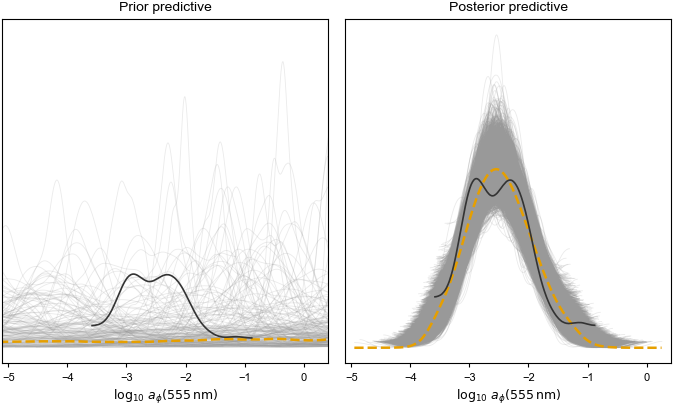

In [ ]:
# SI Figure: Prior vs Posterior PPC (band 555); falls back to posterior-only if no prior saved
band = 555
f, axs = compare_ppc(
    idata_lin, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m1_compare_ppc_{band}.pdf"
)

(<Figure size 700.787x434.488 with 2 Axes>,
 array([<Axes: title={'center': 'Prior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(670\\,\\mathrm{nm})$'>,
        <Axes: title={'center': 'Posterior predictive'}, xlabel='$\\log_{10}\\,a_{\\phi}(670\\,\\mathrm{nm})$'>],
       dtype=object))

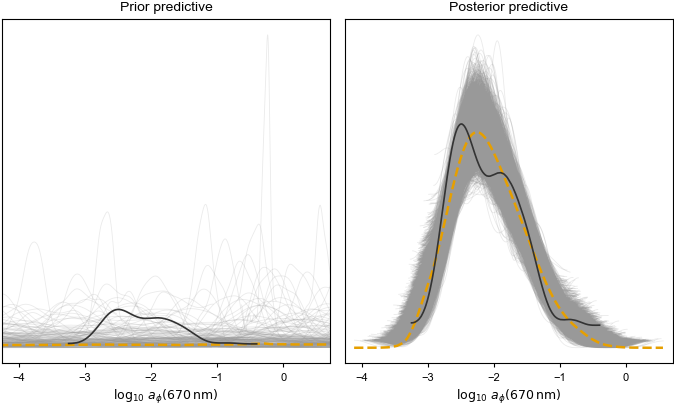

In [ ]:
# SI Figure: Prior vs Posterior PPC (band 670); falls back to posterior-only if no prior saved
band = 670
f, axs=compare_ppc(
    idata_lin, var="likelihood", band=band,
    out=DIR["figs"]/ "si"/ f"figS_m1_compare_ppc_{band}.pdf"
)

(<Figure size 342.52x212.362 with 1 Axes>,
 <Axes: xlabel='Observation # (sorted by observed)', ylabel='$\\log_{10}\\,a_{\\phi}(443\\,\\mathrm{nm})$'>)

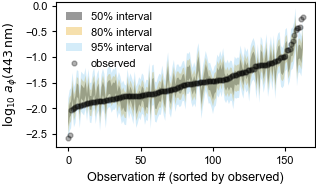

In [11]:
# SI Figure: HDI ribbons vs observed (band 443)
band=443
plot_regression_hdi(
    idata_lin, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_linear_diag.pdf"
)


(<Figure size 342.52x212.362 with 1 Axes>,
 <Axes: xlabel='Observation # (sorted by observed)', ylabel='$\\log_{10}\\,a_{\\phi}(555\\,\\mathrm{nm})$'>)

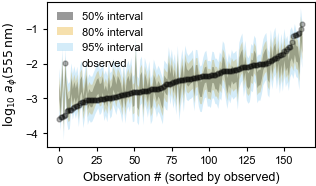

In [12]:
# SI Figure: HDI ribbons vs observed (band 555)
band=555
plot_regression_hdi(
    idata_lin, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_linear_diag.pdf"
)

(<Figure size 342.52x212.362 with 1 Axes>,
 <Axes: xlabel='Observation # (sorted by observed)', ylabel='$\\log_{10}\\,a_{\\phi}(670\\,\\mathrm{nm})$'>)

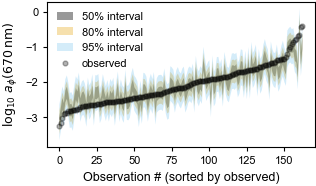

In [13]:
# SI Figure: HDI ribbons vs observed (band 670)
band=670
plot_regression_hdi(
    idata_lin, var="likelihood", band=band, color_obs='black', alpha_scatter=0.3,
    out=DIR["figs"]/ "si"/f"figS_hdi_{band}_linear_diag.pdf"
)

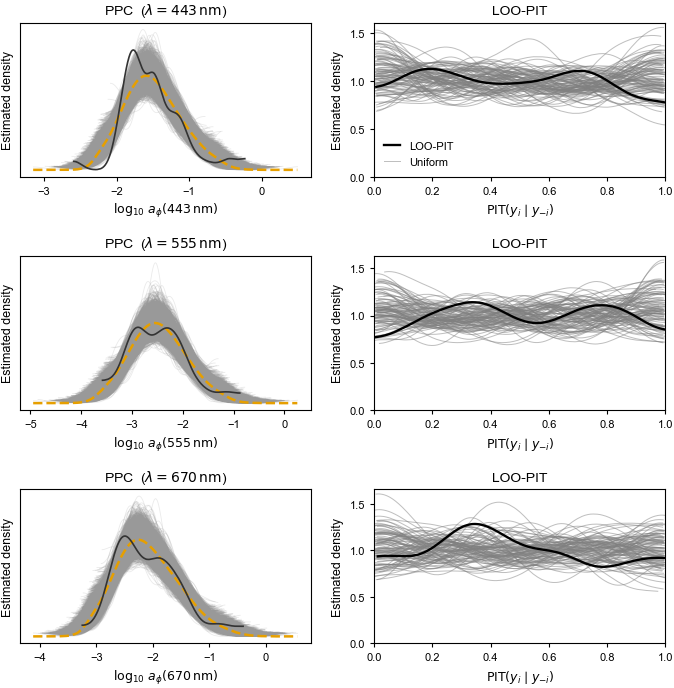

In [20]:

# All three bands in one 3×2 figure
f, axs = plot_ppc_pit_grid(
    idata_lin, var="likelihood",
    out=DIR["figs"]/ "si"/ "figS_ppc_pit_grid_linear_diag.pdf"
)


In [18]:

# (Optional) SI Table: Coverage per band
cov_lin = posterior_coverage(idata_lin, var="likelihood")
cov_lin.to_csv(DIR["results"]/ "coverage_linear_diag.csv", index=False)


> What is coverage here:  the fraction of observations (for that band) whose observed values lie inside the model’s posterior predictive central interval at the given nominal level. If coverage < nominal, the predictive is under-dispersed; if coverage > nominal, it’s over-dispersed. (Note: this is in-sample posterior predictive coverage, not LOO unless you compute LOO predictive draws.)

In [19]:
cov_lin

,interval,band,coverage,nominal
0,95%,443,0.963190,0.95
1,95%,555,0.963190,0.95
2,95%,670,0.963190,0.95
3,80%,443,0.858896,0.80
4,80%,555,0.871166,0.80
5,80%,670,0.834356,0.80
6,50%,443,0.533742,0.50
7,50%,555,0.558282,0.50
8,50%,670,0.570552,0.50


In-sample posterior predictive coverage often skews a bit high (optimistic). That’s normal.

To judge calibration more strictly, rely on LOO-PIT (and/or compute LOO predictive coverage)—those account for re-use of the data.

If LOO-PIT shows a gentle hump near 0.5 (rather than U-shape), that aligns with overdispersion; if it’s close to uniform, you’re fine.

Check whether there are no overly influential values that can undermine PSI-LOO-CV

In [26]:
infl_idx, k_values, loo_result = find_influential_observations(idata_lin)
"Influential Values detected" if len(infl_idx) else "No overly influential values to undermine PSIS-LOO"

'No overly influential values to undermine PSIS-LOO'

#### 7) Save Inference Data object

In [508]:
save_idata(idata_lin, DIR["idata"], "linear_diag")

PosixPath('/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/inferencedata/linear_diag.nc')

### Model 2 — BART mean with diagonal covariance (nonlinear benchmark)

**Why this model**  
The six TOA radiance predictors are **highly correlated** across wavelengths. A tree ensemble like **BART** can absorb collinearity and possible weak nonlinearities/interactions without pre-specifying them. I present this *nonlinear* benchmark **before** the linear baselines to show what additional flexibility buys. It matches the Linear model'sresidual assumption, so differences in performance isolate **mean-function flexibility** to contrast simplicity vs. flexibility.

** Variables (log-domain)
- Predictors per observation $i$: $\mathbf{x}_i \in \mathbb{R}^6$ ordered as $[412,443,490,510,555,670]$ (log$_{10}$ radiances).
- Responses per observation $i$: $\mathbf{y}_i=(y_{i,443},y_{i,555},y_{i,670})^\top$ where $y_{i,k}=\log_{10} a_\phi(\lambda_k)$.
- **No standardization** of predictors (predictive setting).

**Model definition**
I fit **separate BART mean functions per band** with a **shared** hyperparameter setting and **independent Gaussian residuals** across bands (diagonal covariance):
$$
\mu_{i,k} \equiv f_{\lambda_k}(\mathbf{x}_i), \qquad
f_{\lambda_k} \sim \mathrm{BART}(m=10,\ \alpha=0.9,\ \beta=4), \qquad k\in\{443,555,670\}.
$$
$$
y_{i,k}\mid \mu_{i,k},\sigma_k \sim \mathcal{N}(\mu_{i,k},\,\sigma_k^2), 
\qquad \sigma_k \sim \mathrm{HalfNormal}(0.5).
$$
Vector form:
$$
\mathbf{y}_i \sim \mathcal{N}\!\big(\boldsymbol{\mu}_i,\ \mathrm{diag}(\boldsymbol{\sigma}^2)\big),
\qquad
\boldsymbol{\mu}_i = \big(f_{443}(\mathbf{x}_i),f_{555}(\mathbf{x}_i),f_{670}(\mathbf{x}_i)\big)^\top,
\quad
\boldsymbol{\sigma} = (\sigma_{443},\sigma_{555},\sigma_{670})^\top.
$$

**Hyperparameter intent.**  

* $m=10$ (modest ensemble size)
* $\alpha=0.9$ (shallower trees) 
* regularize structure at $N=163$; 
* $\beta=4$ shrinks terminal-node means; 
* $\mathrm{HalfNormal}(0.5)$ is a weakly-informative residual-scale prior per band.

#### 1) Model Code


In [26]:
with pm.Model(coords=coords) as m_bart:
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    σ = pm.HalfNormal('σ', 0.5, dims='λ_aφ')
    μ = pmb.BART('μ', X=X_data, Y=Y_data, m=10, alpha=0.9, beta=4, dims=('λ_aφ', 'obs_idx')).T
    pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

#### 2) Model DAG visualization
- Sanity-check parent/child relationships and tensor shapes.  

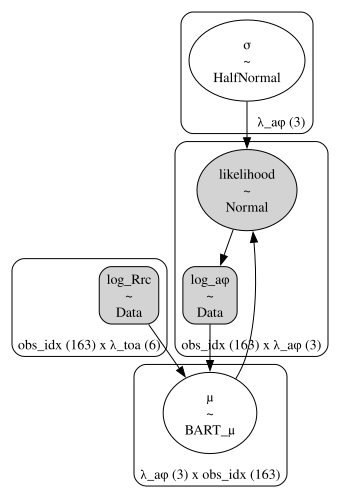

In [436]:
g = m_bart.to_graphviz()
g

**Note on the BART model graph.**  
You may see an arrow from the observed node $\,\texttt{log\_a}\phi\,$ to the BART mean $\mu$ in the Graphviz output. This is **not** part of the generative DAG. The generative story is
$$
\mathbf{x}\;\to\;\mu=f(\mathbf{x})\;\to\;y\sim\mathcal{N}(\mu,\sigma^2),\qquad \sigma\to y,
$$
i.e., $y$ depends on $(\mu,\sigma)$, and $\mu$ depends on $\mathbf{x}$.

The extra arrow reflects **computational/inference dependencies** in PyMC’s implementation of BART: internally, the observed data $y$ are used to form residuals and drive the tree backfitting/update steps. Graphviz shows that implementation detail as a dependency (to support posterior updates), but it **does not** mean the BART **prior** is conditioned on $y$. In other words, treat the arrow as part of the **inference graph**, not the **probabilistic DAG**.


In [507]:
save_model_dag(m_bart, DIR["figs"]/ "si" / "figS_m2_dag.pdf", width="two")

In [29]:
with m_bart:
    idata_bart = pm.sample_prior_predictive()

Sampling: [likelihood, μ, σ]


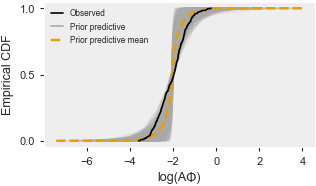

In [509]:
fig, ax = fig_ax(width="one", aspect=0.62)
az.plot_ppc(
    idata_bart, group='prior', kind='cumulative', 
    colors=PPC_COLORS, observed=True, ax=ax)

ax.set_xlabel('log(AΦ)')
ax.set_ylabel('Empirical CDF')
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_m2_prior_ppc.pdf")

#### 4) Posterior sampling (NUTS).**  
- Settings: [chains = 4, tune = 1000 , draws = 2000/chain, target_accept = 0.80 (default)].  
- Stored: `log_likelihood`, `posterior_predictive`, [and `μ` if available].  
**Result notes:** [No warnings/divergences]


In [31]:
with m_bart:
    idata_bart.extend(pm.sample(draws=2000, chains=4, target_accept=0.95))

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details



#### 5) Sampling diagnostics.**  

* Summary statistics, examining
    - $\hat{R}$ to assess convergence of independent MCMC chains
        * should be about 1.0 - 1.01
    - Effective Sample Size (ESS) to verify sufficient independent samples were collected in key areas of the posterior. 
        * should be in the high 100s to 1000s
    - check for r_mcse to confirm posterior sampling was adequate
        * should be much less than 0.05

* Evaluate energy plot checking that:
    * Marginal Energy and Energy transition distribution KDEs overlap well
    * All chains show BFMI > 0.3

* Visualize trace plots checking that:
    * all traces look well mixed (fuzzy caterpillar appearance)
    * satisfactory overlap of parameter marginal posteriors
    * make note which parameter's (if any) marginal posterior overlap '0' 
        - ths can also be confirmed via summary table (hdi_lo and hdi_hi on either side of 0)
There are some warnings about convergence between independent sampling runs. If these are minors, the model is still likely to be OK. The main thing is to make sure that not too many values are beyond a Gelman-Rubin statistic ($\hat{R}$) of 1.01, particularly that I don't get any warnings about Effective Sample Size (ESS).

In [511]:
summ = az.summary(idata_bart, round_to=None)
summ

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"μ[443, 2]",-1.462,0.115,-1.679,-1.250,0.003,0.002,1090.0,1923.0,1.00
"μ[443, 3]",-1.496,0.108,-1.711,-1.305,0.003,0.002,1174.0,1943.0,1.00
"μ[443, 26]",-1.683,0.118,-1.908,-1.467,0.004,0.002,979.0,1814.0,1.01
"μ[443, 31]",-1.408,0.118,-1.626,-1.188,0.004,0.002,1036.0,1889.0,1.00
"μ[443, 32]",-1.503,0.118,-1.718,-1.281,0.004,0.002,1045.0,1905.0,1.01
...,...,...,...,...,...,...,...,...,...
"μ[670, 492]",-2.010,0.186,-2.378,-1.673,0.006,0.003,1074.0,1789.0,1.00
"μ[670, 494]",-1.891,0.185,-2.235,-1.548,0.006,0.004,1110.0,1871.0,1.01
σ[443],0.359,0.031,0.300,0.415,0.001,0.000,1224.0,2539.0,1.00
σ[555],0.500,0.046,0.420,0.589,0.001,0.001,1465.0,2920.0,1.00


In [512]:
summ["rMCSE_mean"] = summ["mcse_mean"] / summ["sd"]
summ["rMCSE_sd"]   = summ["mcse_sd"]   / summ["sd"]
summ[["rMCSE_mean","rMCSE_sd","ess_bulk","ess_tail","r_hat"]].describe()

,rMCSE_mean,rMCSE_sd,ess_bulk,ess_tail,r_hat
count,492.000000,492.000000,492.000000,492.000000,492.000000
mean,0.029543,0.017472,1121.166667,1940.715447,1.003211
std,0.002554,0.002133,90.354679,207.624672,0.004674
min,0.021739,0.000000,897.000000,1295.000000,1.000000
25%,0.027473,0.016216,1057.000000,1813.750000,1.000000
50%,0.028986,0.016949,1121.500000,1941.000000,1.000000
75%,0.031543,0.018349,1187.250000,2073.000000,1.010000
max,0.036496,0.025424,1475.000000,2920.000000,1.010000


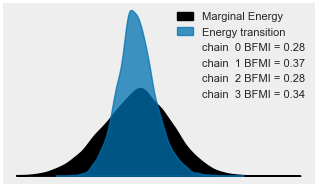

In [513]:
fig, ax = fig_ax()
az.plot_energy(idata_bart, ax=ax)
fig.tight_layout()
save_pnas(fig, DIR["figs"] / "si" / "figS_m2_energy.pdf")

Most of bulk and tail ESS are in the thousands of samples. This suggest good sampling.

Another diagnostic is the Energy plot. This applies to Hamiltonian Monte Carlo (HMC) samplers like the No U-Turn Sampler (NUTS), responsible for sampling continuous regions of the posteriorin, which in this case applies to the variance of the likelihood. Indeed the BART component is not continuous. Thus the mean of the likelihood (μ) is determined by the BART posterior, which is sampled using PG-BART (Particle Gibbs for BART). PG-BART is not a gradient-based method — it does not involve leapfrog integration, energy functions, or momentum resampling. Instead, PG-BART operates on discrete tree structures, which are non-differentiable. In particular PG-BART:
* Uses particle filtering + Gibbs sampling to explore the space of trees.
* Resamples trees based on their fit to the data, without needing any gradients.


The Energy plot for HMC helps assess how efficiently the sampler is exploring the posterior distribution. This plot helps assess how efficiently the sampler is exploring the posterior distribution. It shows two key distributions:

* Marginal Energy: The distribution of the Hamiltonian energy values across all samples. This is essentially a measure of the total "energy" (potential + kinetic) of the system at each sample.
* Energy Transition: The distribution of differences in energy between successive samples (i.e., energy jumps). Ideally, the transitions should be smooth and not show large jumps.

These matter because efficient HMC sampling assumes the energy landscape is smooth and traversable. Large or erratic energy transitions may indicate problems such as:

* Poor geometry (e.g., highly curved posteriors)
* Bad parameter scaling or priors
* Sampling stuck in narrow funnels or high-curvature areas


$⇒$ What BFMI Means:

BFMI = Bayesian Fraction of Missing Information

It quantifies how well the momentum resampling step in HMC is helping explore the energy landscape:
$$BFMI=\frac{Var(marginal energy)}{Var(energy transition)}$$
​

A low BFMI means the sampler isn't drawing enough momentum to explore distant parts of the posterior, which can result in biased samples or poor mixing.

$⇒$ What is a Good BFMI Value?

* BFMI ≥ 0.3 is generally considered acceptable.
* BFMI < 0.2 is a red flag indicating poor exploration and possible divergences.
* Ideally, values closer to 1 are better — indicating momentum is appropriately scaled to traverse the typical set efficiently.

$⇒$ How to Use the Plot:

* Compare the marginal energy and energy transition distributions. If they differ sharply, or if BFMI is low, your sampler may be inefficient.
* In ArviZ, low BFMI is often reported with a warning. There may also be differences in the plot (e.g., the energy transition distribution is narrow relative to the marginal energy).

In [514]:
# Trace (compact) for a small var set — SI only
axs = az.plot_trace(
    idata_bart, compact=True, kind="rank_vlines",
    figsize=(7.0, 4.5))

axs[1, 0].legend(handles=legend_handles)


pp.savefig(DIR["figs"]/"si"/"figS_m2_trace_bart.pdf"); pp.close()

Next is to simulate $log(aΦ)$ from the posterior; posterior predictive checks

In [41]:
with m_bart:
    idata_bart.extend(pm.sample_posterior_predictive(idata_bart))

Sampling: [likelihood]


Output()

In [ ]:
plot_3_way_ppc(
        idata=idata_bart,
        var="likelihood",
        out=DIR["figs"] / "si" / f"figS_m2_ppc.pdf"
    )

NameError: name 'idata' is not defined

In [50]:
with m_bart:
    try:
        _ = pm.compute_log_likelihood(idata_bart, extend_inferencedata=True)
    except ValueError:
        pass

Output()

In [516]:
save_idata(idata_bart, DIR["idata"], "bart_diag")

PosixPath('/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/inferencedata/bart_diag.nc')

In [51]:
loo_results = az.loo(idata_bart)
print(loo_results)

Computed from 8000 posterior samples and 489 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -327.71    20.43
p_loo       68.96        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      489  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [52]:
loo = az.loo(idata_bart, pointwise=True)
k_values = loo.pareto_k.values
influential_idx = (k_values > 0.7).nonzero()[0]
print("Influential observations:", influential_idx)

Influential observations: []


The above suggests an overdispersed model. One way to try to fix this is to introduce a hierarchical structure to infer σ.

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/6069476.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()


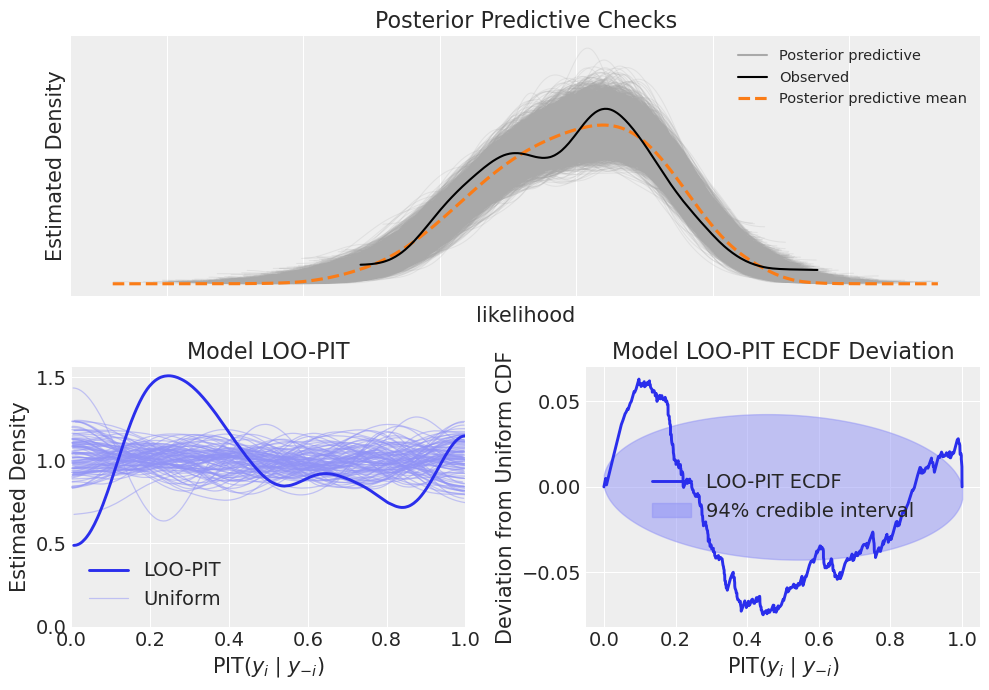

In [74]:
fig_pyld_m1 = plot_ppc_pit(idata_bart)

In [ ]:
idx, k, loo = find_influential_observations(
    idatas["BART (diag)"], threshold=0.7,
    save_csv=DIR["results"] / "loo_pareto_k_bart.csv"
)
print("Influential observations:", idx.tolist())

In [75]:
f1 = fig_pyld_m1['fig_handle']
f1.savefig('./figures/model1_loo_pit.png', dpi=300)

In [ ]:
fig, ax = plot_regression_hdi(idatas["Linear (full)"], var="y", band=443,
                              intervals=(0.95,0.80,0.50),
                              out=DIR["figs"]/ "si" / "figS_ppc_hdi_443_mvn.pdf")

fig, axs = plot_3_way_ppc(idatas["Linear (full)"], var="y", include_all=False,
                          out=DIR["figs"]/ "si" / "figS_ppc_mvn.pdf")

## Model 3 — Hierarchical linear mean with diagonal $\Sigma$ (partial pooling)

**1) Model specification (log-domain).**  
- Linear mean with **partial pooling** on intercepts/slopes (uncentered); independent residuals (diagonal $\Sigma$).  
- Observed variable name: `likelihood`.  
**Result notes:** [hyperprior settings; rationale → ______]



---
**2) Model DAG visualization.**  
- Sanity-check hierarchical structure and dims.  
**Result notes:** [any issues with $\alpha/\beta$ shapes? → ______]  
**Artifact:** [DAG fig path → ______]



---
**3) Prior predictive check (gate).**  
- Visualize prior predictive; confirm plausibility.  
**Result notes:** [adequate ranges? → ______]  
**Artifact:** [prior PPC fig path → ______]



---
**4) Posterior sampling (NUTS).**  
- Settings: [chains = __, tune = __, draws = __, target\_accept = __, seed = __].  
- Stored: `log_likelihood`, `posterior_predictive`, [`μ` deterministic if saved].  
**Result notes:** [runtime/any warnings → ______]



---
**5) Sampling diagnostics.**  
- **Summary:** $\max\hat{R}=$ ___; $\min$ ESS\_bulk = ___; ESS\_tail = ___; MCSE small.  
- **Trace plots:** [overlap? mixing? → ______]  
- **Energy/BFMI:** [divergences? BFMI? tree depth? → ______]  
**Artifacts:** [optional diag table/trace fig paths → ______]



---
**6) Posterior predictive checks & log-likelihood.**  
- PPC by band/aggregated; pointwise `log_likelihood`.  
**Result notes:** [any residual structure hinted? → ______]  
**Artifacts:** [PPC figs → ______; loglik saved → ______]



#### 7) Save Inference Data



---
**Diagonal-$\Sigma$ comparison (Models 1–3).**  
- **ΔELPD ranks & SEs:** [paste from compare\_diag\_only → ______]  
- **Conclusion:** [“Hier-Linear (diag) > Linear (diag) but overlapping SE ⇒ small gain; given fit time, proceed to MVN with flat linear mean.” → ______]



---
**Residual correlation check (SI).**  
- Off-diagonal residual correlation posteriors vs ROPE $\pm 0.05$: [in/ out? → ______]  
**Artifact:** [figS\_resid\_correlation\_\<tag\>.pdf → ______]


## Calibration Results

### 1. On Calibration and Limited Data
In probabilistic modeling, calibration refers to the alignment between predicted probabilities and observed outcomes. For Bayesian models, this means that the posterior predictive distributions should meaningfully capture the range and uncertainty of future (unseen) data. When models are well-calibrated, the intervals they assign to predictions are trustworthy: a 95% interval contains the true value approximately 95% of the time. This is particularly important in low-data regimes, such as the present — a dataset of only 163 observations — where traditional train/test splits can introduce spurious patterns or omit key variability. Instead of discarding data to simulate "held-out" conditions, I rely on leave-one-out cross-validation (LOO) paired with posterior predictive checks, allowing me to fully exploit available data while still validating generalization.

### 2. LOO-PIT and Visual Calibration Checks
I use LOO-PIT (Leave-One-Out Probability Integral Transform) as a diagnostic to evaluate model calibration. For each observation $y_i$, I fit the model leaving $y_i$ out, generate its posterior predictive distribution, and compute the cumulative distribution function (CDF) at $y_i$. If the model is well-calibrated, these CDF-transformed values should be uniformly distributed across [0, 1]. I visualize these using three complementary plots: a histogram of the PIT values, a kernel density estimate (KDE) as a smoothed version of the histogram, and an ECDF deviation plot, which shows how far the empirical cumulative distribution deviates from the uniform line. These combined provide a multi-faceted picture of model calibration.

### 3. Calibration Diagnostics per Wavelength
* **AΦ(443)**: 
    - There is a mild low bias with signs of underdispersion suggesting mild overconfidence
    - The model tends to underpredict the true values
    - Its uncertainty intervals are narrower than warranted. 
* **AΦ(555)** 
    - The PIT values show only a shallow U-shape and very small ECDF deviations, 
    - This suggests mild underdispersion but no meaningful bias. 
    - This component appears well-calibrated overall. 
* **AΦ(670)**: 
    - The dominant feature is a strong low bias.
    - This is shown by the skewed histogram and monotonic deviation in the ECDF plot.
    - The model systematically predicts too low for this band, 
    - There's, however, no strong evidence of misestimated variance.

### 4. Model-Level and Target-Specific Recommendations
***Model Level Recommendations -*** there’s consistent evidence of underdispersion, which likely stems from a shared or overly constrained variance prior (in this case, a HalfNormal(0.5) prior on σ). A modestly broader or hierarchical prior on σ may help address this. <br>
***Band Level Recommendations -*** To correct the bias in AΦ(443) and especially AΦ(670), consider increasing model flexibility: allow band-specific noise parameters, or include interaction terms or nonlinear components that better capture residual structure. For AΦ(670) in particular, investigate potential covariates that might explain systematic underprediction, or consider introducing a band-specific bias term if justified by domain knowledge. Overall, the model is reasonable but benefits from modest adjustments to both dispersion modeling and output-specific calibration.

In [ ]:
# All targets aggregated, MVN model
compare_ppc(idatas["Linear (full)"], var="y",
            out=DIR["figs"]/"si"/"figS_prior_vs_posterior_all.pdf")

# Single band (443 nm), BART model
compare_ppc(idatas["BART (diag)"], var="y", band=443,
            out=DIR["figs"]/"si"/"figS_prior_vs_posterior_443_bart.pdf")

Not much difference. Let's try to increase the model complexity a bit more, by doubling the number of trees to 20.

This works quite well. But could it sample faster? Hierarchical? Zerosum Normal, contrary to all expectations, didn't work 

---
## Hierarchial model

In [284]:
# Hierarchical linear model with uncentered parameterization
with pm.Model(coords=coords) as m_hier_lin: 
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    α_μ = pm.Normal('α_μ', 0, 2)
    β_μ = pm.Normal('β_μ', 0, 2)
    α_σ = pm.HalfNormal('α_σ', 1)
    β_σ = pm.HalfNormal('β_σ', 1)

    α_center = pm.Normal('α_center', 0, 1, dims='λ_aφ')
    β_center = pm.Normal('β_center', 0, 1, dims=['λ_toa', 'λ_aφ'])
    α = pm.Deterministic('α', α_center * α_σ + α_μ, dims='λ_aφ')
    β = pm.Deterministic('β', β_center * β_σ + β_μ, dims=['λ_toa', 'λ_aφ'])
    μ = α + X_data @ β
    σ = pm.Exponential('σ', 1, dims='λ_aφ')
    likelihood = pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

In [286]:
with m_hier_lin:
    idata_hier_lin = pm.sample_prior_predictive()
    idata_hier_lin.extend(
        pm.sample(chains=4, draws=2000, tune=2000,
                  nuts_sampler_kwargs=dict(target_accept=0.95, max_treedepth=15)
                  )
        )
    pm.sample_posterior_predictive(idata_hier_lin, extend_inferencedata=True)
    pm.compute_log_likelihood(idata_hier_lin, extend_inferencedata=True)

Sampling: [likelihood, α_center, α_μ, α_σ, β_center, β_μ, β_σ, σ]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α_μ, β_μ, α_σ, β_σ, α_center, β_center, σ]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 264 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [likelihood]


Output()

Output()

In [287]:
az.summary(idata_hier_lin, kind='diagnostics').r_hat.value_counts(normalize=True).round(3) * 100

r_hat
1.01    53.1
1.00    46.9
Name: proportion, dtype: float64

In [288]:
az.summary(idata_hier_lin, kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α_μ,0.030,0.027,446.0,732.0,1.01
β_μ,0.043,0.023,219.0,395.0,1.01
α_center[443],0.032,0.017,505.0,727.0,1.01
α_center[555],0.025,0.012,536.0,1322.0,1.01
α_center[670],0.027,0.012,513.0,1146.0,1.01
"β_center[412, 443]",0.018,0.008,443.0,1103.0,1.01
"β_center[412, 555]",0.021,0.009,470.0,1348.0,1.01
"β_center[412, 670]",0.018,0.008,487.0,1115.0,1.01
"β_center[443, 443]",0.022,0.011,642.0,1544.0,1.01
"β_center[443, 555]",0.027,0.012,645.0,1672.0,1.01


/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/6069476.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()


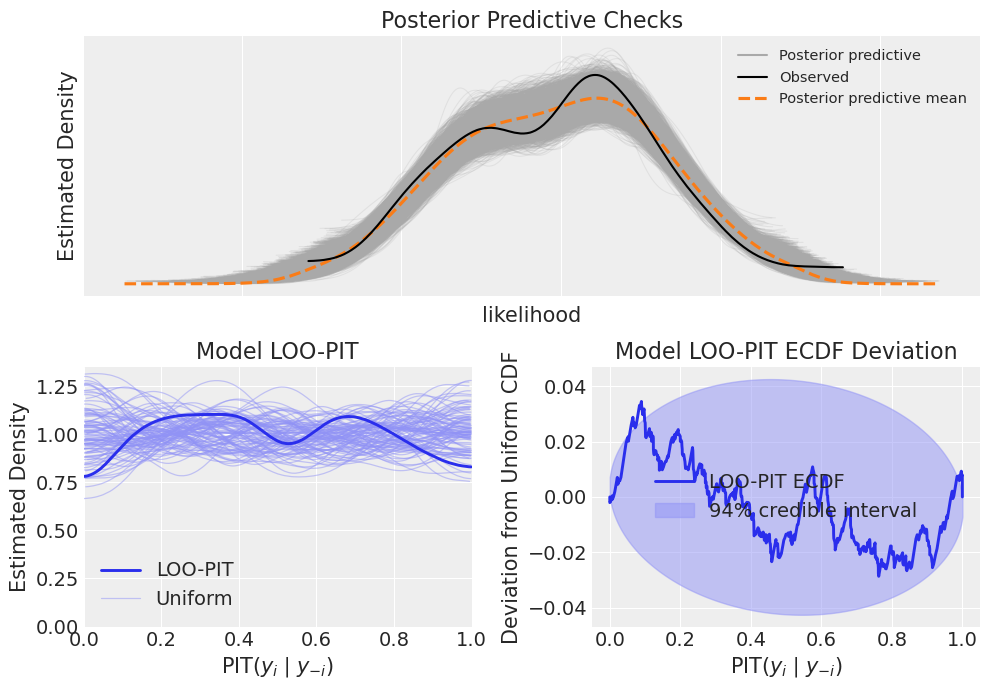

In [336]:
fig_pyld_m_hier_lin = plot_ppc_pit(idata_hier_lin)

In [517]:
save_idata(idata_hier_lin, DIR["idata"], "hier_lin_diag")

PosixPath('/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/inferencedata/hier_lin_diag.nc')

In [ ]:
comparison_2 = az.compare(
    dict(
        bart_variant1=idata_bart, 
        model_hier_lin=idata_hier_lin,
        model_lin=idata_lin
    ),
    ic='loo', method='BB-pseudo-BMA')

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [455]:
comparison_2

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model_hier_lin,0,-11.045478,24.456515,0.000000,9.999730e-01,22.921159,0.000000,False,log
model_lin,1,-30.680171,19.208789,19.634693,2.702051e-05,22.118887,4.840338,False,log
bart_variant_4,2,-309.862997,93.280528,298.817519,5.490728e-110,21.508814,16.409784,True,log
bart_variant1,3,-327.712058,68.960161,316.666580,4.748224e-117,20.207528,16.762460,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

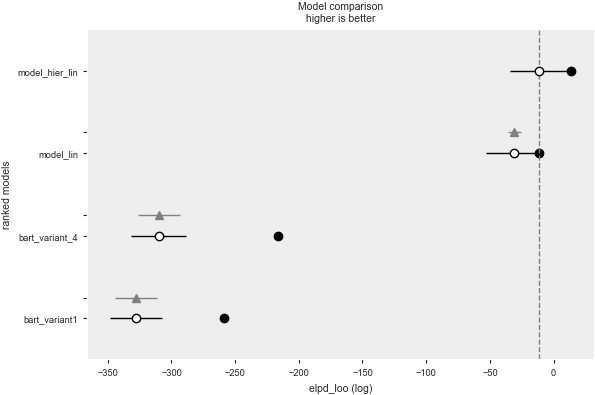

In [456]:
az.plot_compare(comparison_2, plot_ic_diff=True, insample_dev=True)


Pooling structure. I began with hierarchical priors having scalar hyperparameters (one global mean and one global scale shared across wavelengths), which yields partial pooling: band-specific parameters shrink toward a common center with a common strength. 
Given the warnings regarding $\hat{R}$ I did the following chainges:
To allow between-band heterogeneity while still sharing information, I augmented this to vector hyperpriors—band-specific prior means and scales—tied together by scalar hyper-hyperpriors (a global location and a global scale multiplier). This retains partial pooling (information borrowing across bands) but relaxes it so that each band may deviate from the global pattern when supported by the data. Model choice was guided by PSIS-LOO and posterior predictive calibration.

In [202]:
# data preparations (same as your original code)
x_idx, x_names = X.columns.factorize()
y_idx, y_names = Y.columns.factorize()
λ =   [li.split('Rrc_')[-1] for li in x_names]
λ_aph =   [li.split('aph')[-1] for li in y_names]
coords= {
    'obs_idx': X.index,
    'λ_toa': λ,
    'λ_aφ' : λ_aph
}

In [293]:
# Hierarchical linear model with uncentered parameterization
with pm.Model(coords=coords) as m_vec_centered_beta: 
    X_data = pm.Data('log_Rrc', X.values, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y.values, dims=['obs_idx', 'λ_aφ'])

    α_μk = pm.Normal("α_μk", 0.0, 2.0, dims="λ_aφ")
    α_σk = pm.Gamma("α_σk", 2.0, 2.0, dims="λ_aφ")
    α    = pm.Normal("α", α_μk, α_σk, dims="λ_aφ")            # CENTERED

    β_σk = pm.Gamma("β_σk", 2.0, 2.0, dims="λ_aφ")            # per-band; mode=0.5
    β    = pm.Normal("β", 0.0, β_σk[None, :], dims=["λ_toa","λ_aφ"])  # CENTERED


    
    μ = α + X_data @ β
    σ = pm.Exponential('σ', 1, dims='λ_aφ')
    likelihood = pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

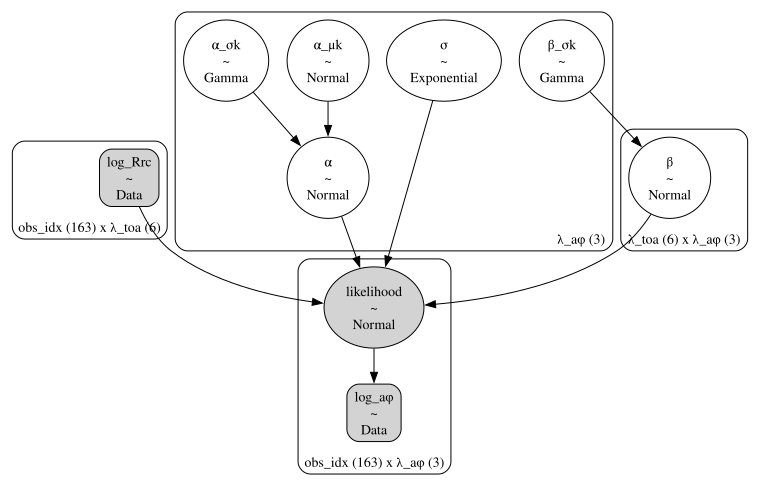

In [294]:
g= m_vec_centered_beta.to_graphviz()
g

In [295]:
with m_vec_centered_beta:
    idata_vec_centered_beta = pm.sample_prior_predictive()
    idata_vec_centered_beta.extend(
        pm.sample(
            chains=4, draws=2000,
            #tune=2500,
            #nuts_sampler_kwargs=dict(target_accept=0.99, #max_treedepth=15))
            )
        )
    pm.sample_posterior_predictive(idata_vec_centered_beta, extend_inferencedata=True)
    pm.compute_log_likelihood(idata_vec_centered_beta, extend_inferencedata=True)

Sampling: [likelihood, α, α_μk, α_σk, β, β_σk, σ]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α_μk, α_σk, α, β_σk, β, σ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 153 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Sampling: [likelihood]


Output()

Output()

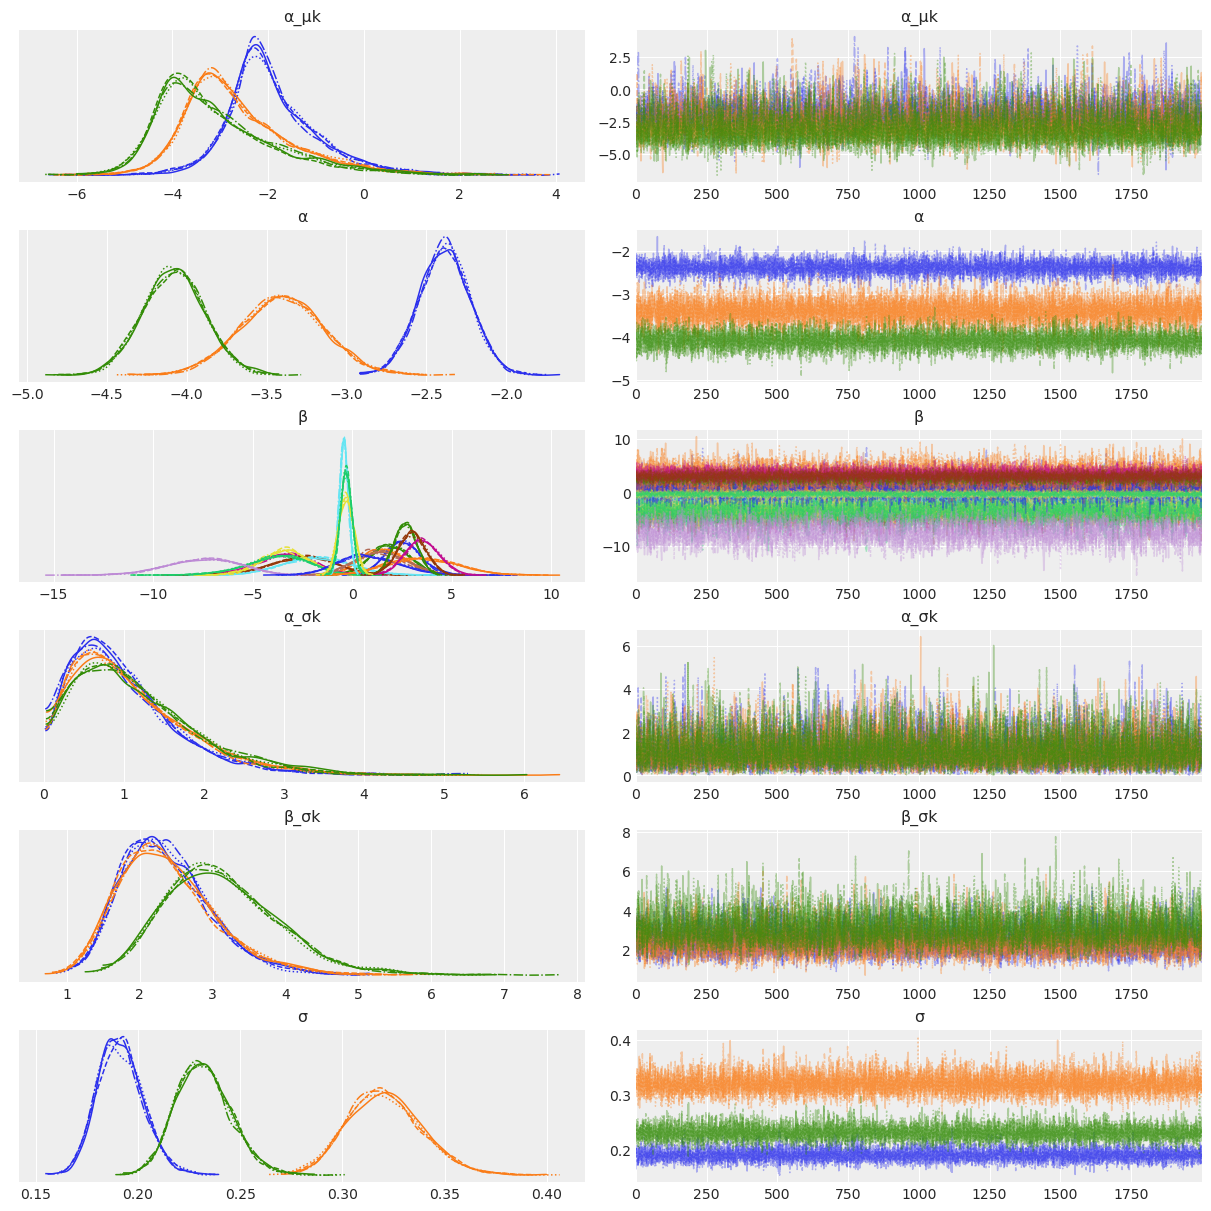

In [299]:
axes = az.plot_trace(idata_vec_centered_beta)

In [300]:
az.summary(idata_vec_centered_beta, kind='diagnostics').round(3)

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α_μk[443],0.017,0.022,4640.0,3288.0,1.0
α_μk[555],0.021,0.021,3836.0,3670.0,1.0
α_μk[670],0.021,0.019,4374.0,4229.0,1.0
α[443],0.002,0.002,7421.0,6054.0,1.0
α[555],0.003,0.003,8954.0,6582.0,1.0
α[670],0.002,0.002,9007.0,6141.0,1.0
"β[412, 443]",0.016,0.010,3045.0,4016.0,1.0
"β[412, 555]",0.021,0.014,3213.0,3625.0,1.0
"β[412, 670]",0.015,0.011,4434.0,5222.0,1.0
"β[443, 443]",0.026,0.017,3143.0,3574.0,1.0


<Axes: >

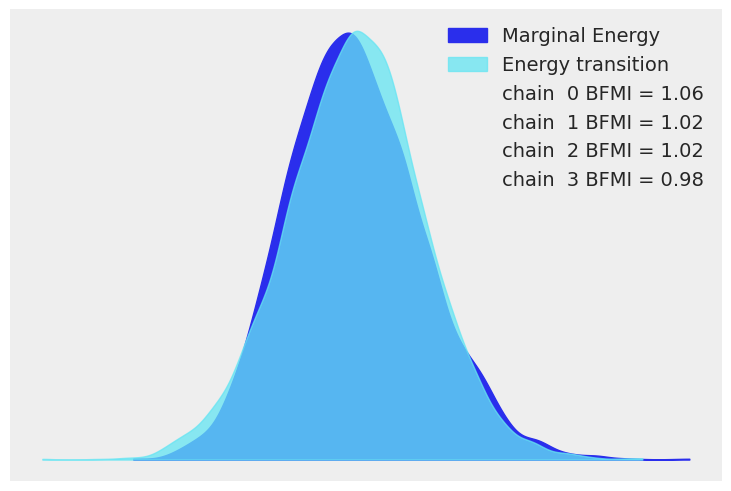

In [301]:
az.plot_energy(idata_vec_centered_beta)

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:233: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


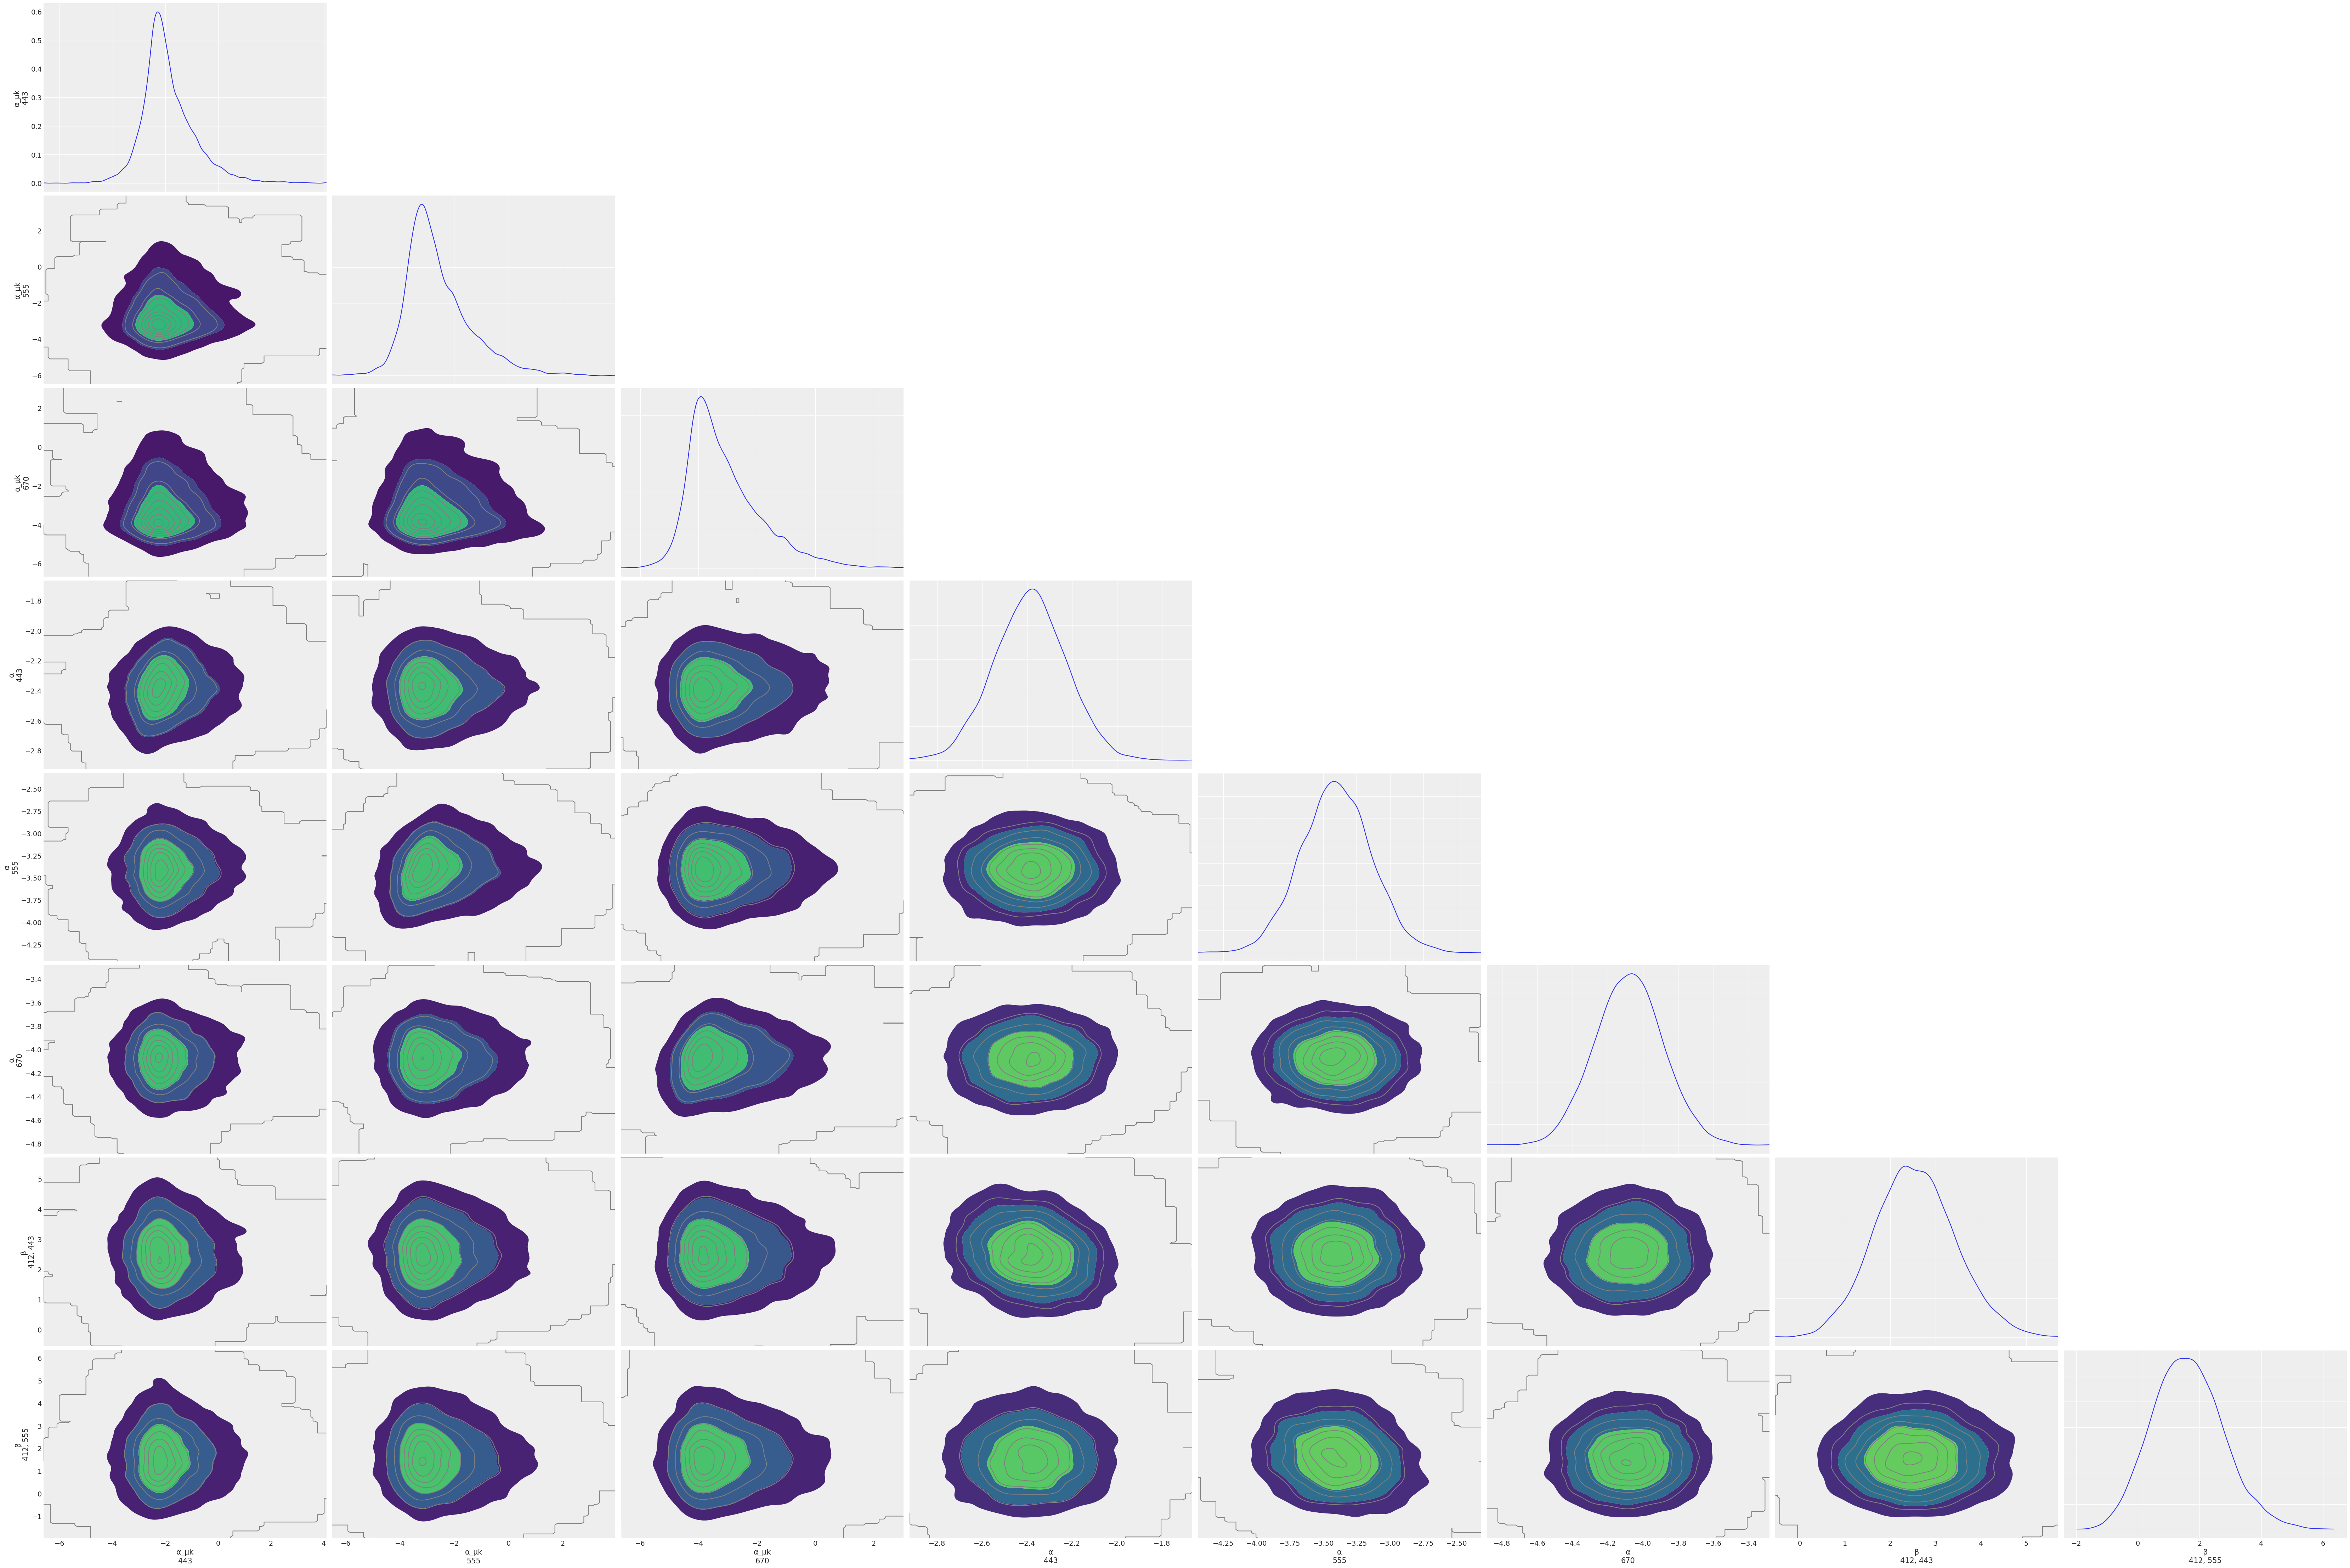

In [302]:
az.plot_pair(idata_vec_centered_beta, kind='kde', marginals=True);

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/6069476.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()


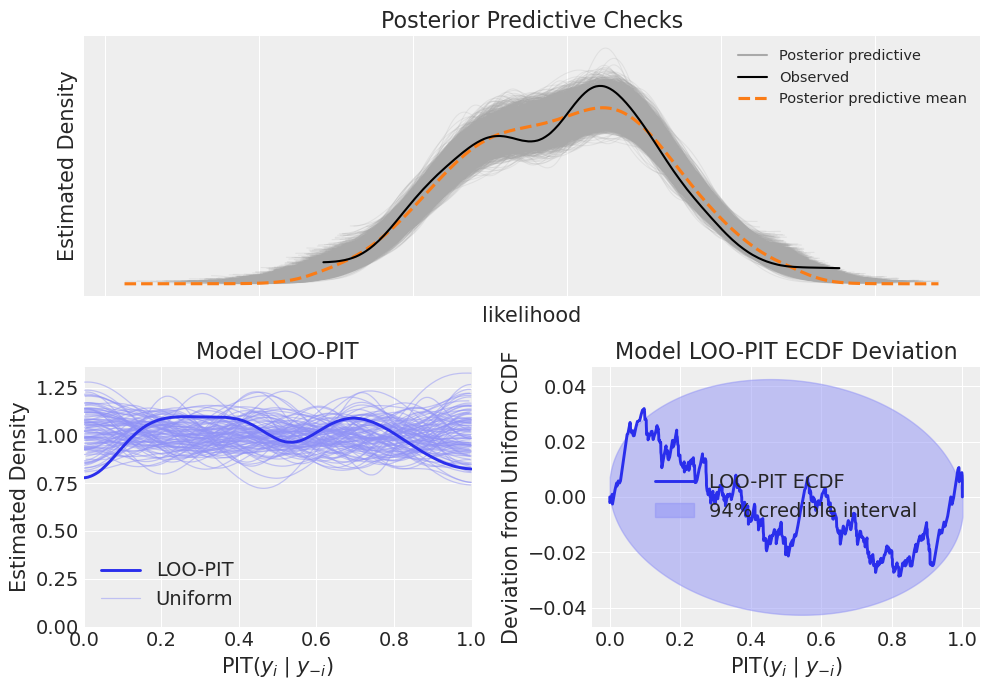

In [337]:
fig_pyld_hier_lin_mvec_cent_beta = plot_ppc_pit(idata_vec_centered_beta)

### Target Cross-Correlation Analysis


In [ ]:
# Build residual draws for a linear model that exposes posterior α, β (or μ)
def residual_draws_from_linear(idata, X, var="likelihood"):
    # prefer μ if saved; else reconstruct from α, β
    if "μ" in idata.posterior:
        mu = idata.posterior["μ"].stack(sample=("chain","draw")).transpose("sample","obs_idx","λ_aφ").values
    else:
        α = idata.posterior["α"].stack(sample=("chain","draw")).transpose("sample","λ_aφ").values      # (S,K)
        β = idata.posterior["β"].stack(sample=("chain","draw")).transpose("sample","λ_toa","λ_aφ").values  # (S,6,K)
        mu = α[:, None, :] + np.einsum("ij,spj->spi", X, β)  # (S,N,K)

    y_obs = idata.observed_data[var].values  # (N,K)
    resid = y_obs[None, :, :] - mu           # (S,N,K)
    return resid



# Correlation analysis plot (fix labels to 443/555/670)

def corr_matrix(x):  # x: (N,K)
    return np.corrcoef(x.T)

def plot_corr_analysis(resid):
    corrs = np.array([corr_matrix(r) for r in resid])  # (S,K,K)
    band_labels = ["aph443","aph555","aph670"]  # K=3 here
    pairs = list(combinations(range(corrs.shape[1]), 2))
    ncols = min(3, len(pairs)); nrows = int(np.ceil(len(pairs)/ncols))
    fig, axes = pp.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows)); axes = np.atleast_1d(axes).ravel()
    for ax, (i, j) in zip(axes, pairs):
        rho_ij = corrs[:, i, j]
        az.plot_posterior(rho_ij, hdi_prob=0.9, ref_val=0.0, ax=ax, rope=[-0.05, 0.05])
        ax.set_title(f"corr(resid_{band_labels[i]}, resid_{band_labels[j]})")
    for k in range(len(pairs), len(axes)): axes[k].axis("off")
    fig.suptitle("Posterior distribution of residual correlations (90% HDI)", y=1.02)
    pp.tight_layout()
    return fig, axes

fig_corr, _ = plot_corr_analysis(resid)
save_pnas(fig_corr, DIR["figs"] / "si" / "figS_resid_correlation_hier_linear_diag.pdf")


In [ ]:
# Example: run on the linear model with diagonal covariance
resid_lin = residual_draws_from_linear(idata_lin, X, var="likelihood")  # (S,N,K)
S, N, K = resid_lin.shape

In [ ]:
# Example: run on the BART model with diagonal covariance
resid_bart = residual_draws_from_linear(idata_bart, X, var="likelihood")  # (S,N,K)
S, N, K = resid_bart.shape

In [ ]:
# Example: run on the hierarchical model with diagonal covariance
resid_hier_lin = residual_draws_from_linear(idata_hier_lin, X, var="likelihood")  # (S,N,K)
S, N, K = resid_hier_lin.shape

In [304]:
# y_obs: (n, K)
y_obs = idata_bart.observed_data["likelihood"].values
# posterior predictive: (chain, draw, n, K)
y_ppc = idata_bart.posterior_predictive["likelihood"].values
chains, draws, n, K = y_ppc.shape
S = chains * draws
y_ppc = y_ppc.reshape((S, n, K))

# residuals for each draw
resid_bart = y_obs[None, :, :] - y_ppc  # (S, n, K)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/2041707944.py:28: UserWarning: The figure layout has changed to tight
  pp.tight_layout()


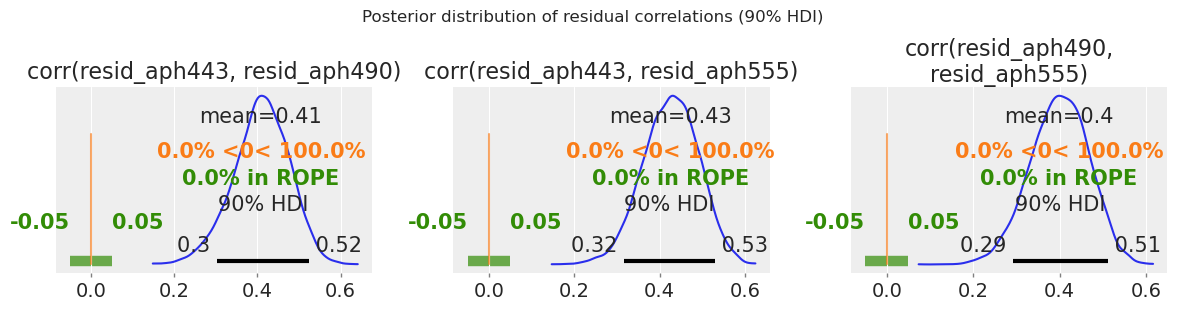

In [305]:
from itertools import combinations
# correlation matrices per draw (S, K, K)
def corr_matrix(x):  # x: (n, K)
    return np.corrcoef(x.T)

def plot_corr_analysis(resid):
    corrs = np.array([corr_matrix(r) for r in resid])

    band_labels = ["aph443","aph490","aph555"][:K]  # adjust labels if needed

    # Plot posterior for each off-diagonal correlation with HDIs and ref line at 0
    pairs = list(combinations(range(K), 2))
    ncols = min(3, len(pairs))
    nrows = int(np.ceil(len(pairs)/ncols))
    fig, axes = pp.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (i, j) in zip(axes, pairs):
        rho_ij = corrs[:, i, j]  # (S,)
        az.plot_posterior(rho_ij, hdi_prob=0.9, ref_val=0.0, ax=ax, rope=[-0.05, 0.05])
        ax.set_title(f"corr(resid_{band_labels[i]}, resid_{band_labels[j]})")

    # Hide any unused axes
    for k in range(len(pairs), len(axes)):
        axes[k].axis("off")

    fig.suptitle("Posterior distribution of residual correlations (90% HDI)", y=1.02)
    pp.tight_layout()

plot_corr_analysis(resid_bart)

#### 2. Linear Regression

In [306]:
# y_obs: (n, K)
y_obs = idata_lin.observed_data["likelihood"].values
# posterior predictive: (chain, draw, n, K)
y_ppc = idata_lin.posterior_predictive["likelihood"].values
chains, draws, n, K = y_ppc.shape
S = chains * draws
y_ppc = y_ppc.reshape((S, n, K))

# residuals for each draw
resid_lin = y_obs[None, :, :] - y_ppc  # (S, n, K)

I defined a region of practical equivalence (ROPE) for residual cross-correlations as $[−0.05,0.05]$. For three outputs, this corresponds to $≤10\%$ inflation in the variance of a pooled residual summary $(1+2ρ).

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/2041707944.py:28: UserWarning: The figure layout has changed to tight
  pp.tight_layout()


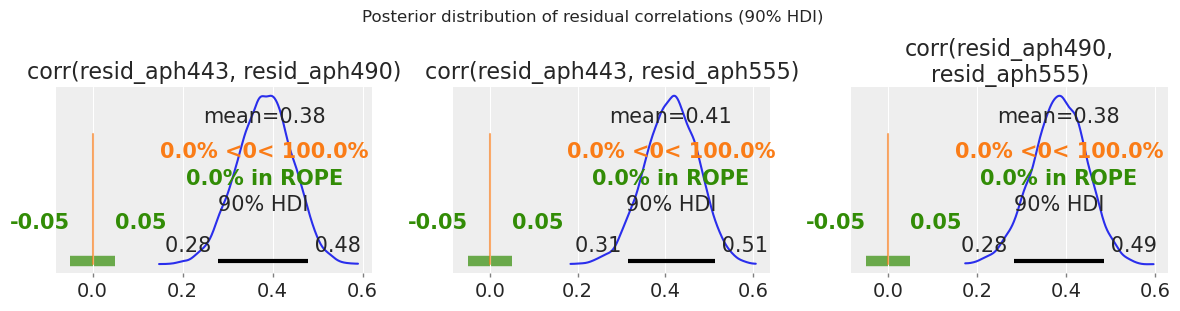

In [307]:
plot_corr_analysis(resid_lin)

In [310]:
# y_obs: (n, K)
#y_obs_h = idata_lin.observed_data["likelihood"].values
# posterior predictive: (chain, draw, n, K)
y_ppc = idata_hier_lin.posterior_predictive["likelihood"].values
chains, draws, n, K = y_ppc.shape
S = chains * draws
y_ppc = y_ppc.reshape((S, n, K))

# residuals for each draw
resid_hl = y_obs[None, :, :] - y_ppc  # (S, n, K)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/2041707944.py:28: UserWarning: The figure layout has changed to tight
  pp.tight_layout()


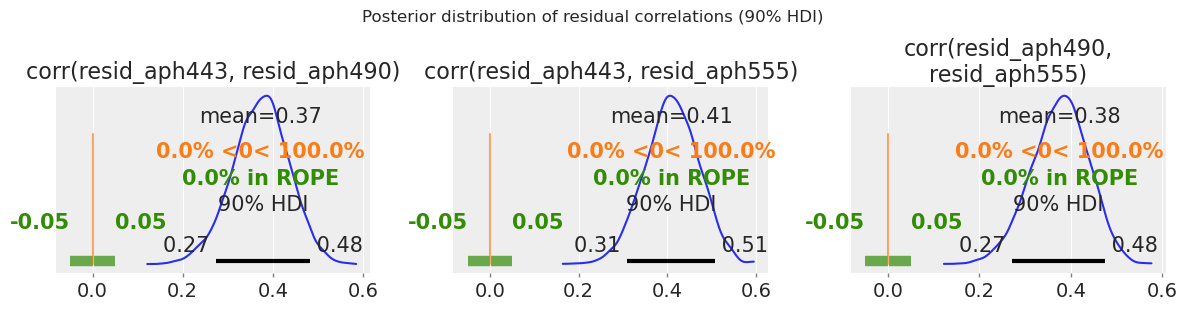

In [311]:
plot_corr_analysis(resid_hl)

In both cases that’s a clear signal: if all three residual cross-correlation posteriors have 0% mass inside even ±0.10, the independent-errors model is misspecified. The principled next step is to model a joint residual covariance—MVN likelihood with an LKJ prior (SUR-style).

---
## B — Covariance matters (full Σ)

### Model 4 — Linear mean (flat) with full Σ(MVN; final model for main text)

**1) Model specification (log-domain).**  
- Linear mean; **full residual covariance** via LKJ prior on correlations (MVN likelihood).  
- Observed variable name: `likelihood`.  
**Result notes:** [LKJ $\eta$ used; sd prior; any identifiability notes → ______]

---
**2) Model DAG visualization.**  
- Sanity-check Cholesky/covariance parameterization and dims.  
**Result notes:** [any shape concerns? → ______]  
**Artifact:** [DAG fig path → ______]

---
**3) Prior predictive check (gate).**  
- MVN prior predictive spans plausible ranges and cross-band structure.  
**Result notes:** [evidence of over/under-dispersion a priori? → ______]  
**Artifact:** [prior PPC fig path → ______]

---
**4) Posterior sampling (NUTS).**  
- Settings: [chains = __, tune = __, draws = __, target\_accept = __, seed = __].  
- Stored: `log_likelihood`, `posterior_predictive`, `μ`, [covariance params].  
**Result notes:** [runtime; adaptation comments → ______]

---
**5) Sampling diagnostics.**  
- **Summary:** $\max\hat{R}=$ ___; ESS\_bulk/tail; MCSE small.  
- **Trace plots:** [overlap/stationarity → ______]  
- **Energy/BFMI:** [divergences? BFMI? tree depth? → ______]  
**Artifacts:** [optional diag table/trace fig paths → ______]

---
**6) Posterior predictive checks & log-likelihood.**  
- PPC per band and aggregated; pointwise `log_likelihood`.  
**Result notes:** [fit quality by band → ______]  
**Artifacts:** [PPC figs → ______; loglik saved → ______]

---
**7) Fit, generalizability, calibration (paper figures).**  
- **PSIS-LOO (ELPD):** value = ___; SE = ___; **final ranking vs others** below.  
- **Pareto-$k$:** count(k>0.7) = ___; 0.5–0.7 = ___ (indices saved at → ______).  
- **Observed vs Predicted (main Fig. 1):** [short read → ______]  
- **LOO-PIT (main Fig. 2):** [shape deviations from uniform (U, ∩, skew)? → ______]  
- **Coverage (main Fig. 3):** 443 = __/__ /__; 555 = __/__ /__; 670 = __/__ /__.  
**Artifacts:**  
- `figs/fig1_obs_vs_pred_mvn.pdf` — caption stub: [______]  
- `figs/fig2_loo_pit_mvn.pdf` — caption stub: [______]  
- `figs/fig3_coverage_mvn.pdf` — caption stub: [______]

---
**Final model comparison (all models).**  
- `compare_and_save({...}, tag="model_compare")`  
- **ΔELPD (winner vs runner-up) = ____ (SE ____).**  
- **Conclusion for main text:** [MVN linear selected; others in SI; brief rationale → ______]  
**Artifacts:** [results/model\_compare.csv; results/table1\_model\_compare.tex → ______]


Role of the cholesky decomposition in the model below: The Cholesky decomposition is used to express the covariance matrix (Σ) in terms of its Cholesky factor (L). This allows me to work with the lower-dimensional representation (L) instead of the full covariance matrix (Σ), which can be computationally expensive and numerically unstable to handle directly. By modeling L, I ensure that Σ remains positive definite, which is a requirement for valid covariance matrices.

## Understanding the Covaraince Structure in the Multivariate Model

### 1. Cholesky Factorization of Covariance Matrix with LKJ Prior

* Corresponds to this line in the model:
```python

packed_Lcov, R_corr, σ_resid = pm.LKJCholeskyCov(
        'L_parts', n=K, eta=2, # weakly informative prior
        sd_dist=pm.Exponential.dist(1.0),compute_corr=True )
```
* Goal: put a prior on a K×K covariance matrix via a correlation + scale decomposition.
* $n=K$: dimension of the residual vector (here, K=3 for aph at 443, 555, 670nm)
* $\eta=2.0$: LKJ concentration:
  * $\eta=1.0$ is uniform over correlation matrices
  * $\eta>1.0$ increasingly shrinks correlations toward zero
  * $eta=2-3$ mild shrinkage toward zero correlations
  * $\eta<1.0$ increasingly shrinks correlations toward -1 and +1
* `sd_dist=pm.Exponential.dist(1.0)`: prior on the K residual / marginal standard deviations (σ_resid)
  *  Swapable HalfNormal.dist(scale), HalfSutdentT.dist(scale) HalfCauchy.dist(scale), etc. depending on the desired tail behavior or scaling requirement of the data.
* `compute_corr=True` returns:
    * packed_Lcov: the K(K+1)/2 non-redundant elements of the lower-triangular Cholesky factor of the covariance matrix (L)
    * R_corr: the K×K correlation matrix
    * σ_resid: the K marginal standard deviations (the diagonal of the covariance matrix); a positive vector of length K

Intuition: This draws a random correlation matrix $R$ from the $LKJ(\eta)$ prior, then scales it by random standard deviations to get a random covariance matrix $\Sigma = diag(\sigma) R diag (\sigma)$. The Cholesky factorization (L) is computed internally and returned in packed form for computational efficiency.




### 2. Build the Cholesky Factor (L)
* Corresponds to this line in the model:
```python
L = pm.Deterministic('L_chol', 
                         pt.diag(σ_resid) @ pt.linalg.cholesky(R_corr),
                         dims=('λ_aφ', 'λ_aφ'))
```
* Goal: construct the Cholesky factor (L) of the covariance matrix (Σ)
* `pt.diag(σ_resid)`: turns the length-K vector of standard deviations into a K×K diagonal matrix $D=diag(\sigma)$
* `pt.linalg.cholesky(R_corr)`: computes the (lower-triangular) Cholesky  $C$ of the correlation matrix $R$ such that $R = CC^T$
* The Matrix multiplication `@` product $L = DC$ is the Cholesky factor of the covariance matrix: 
$$LL^T =(DC)(DC)^T = DCC^TD = DRD =\Sigma$$
* Why build L this way? 
  * avoids having to unpack triangles directly
  * clear separation of scales (σ) and correlations (R)
  * easy to understand: covaraince = scales × correlations × scales
* L is saved to the trace for later inspection and posterior predictive checks
* dims=['λ_aφ', 'λ_aφ'] tages the two axes with output-band coordinate for clarity in plotting.

### 3. Store implied covariance for sanity checks
* Corresponds to this line in the model:
```python
Σ = pm.Deterministic('Σ', L @ L.T, dims=('λ_aφ', 'λ_aφ'))
```
* Not needed for samplibg, but useful because...
* Confirms $\Sigma = LL^T$ as the covariance matrix
* Great for diagnostics (e.g. posterior heatmap of covariance, etc) 

### 4. Store correlation matrix and standard deviations for diagnostics
* Corresponds to these lines in the model:
```python
pm.Deterministic('R_corr', R_corr, dims=('λ_aφ', 'λ_aφ'))
pm.Deterministic('σ_resid', σ_resid, dims='λ_aφ')
```
* Again Not needed for sampling, but useful 
* Allows direct plotting of residual correlations and residual standard deviations for each band without having to reconstruct from L or Σ.

### 5. Use L in the Multivariate Normal Likelihood
* Corresponds to this line in the model:
```python
likelihood = pm.MvNormal(
        'likelihood', mu=μ, chol=L,
        observed=Y_data, dims=['obs_idx', 'λ_aφ']
        )
```
* The multivariate normal likelihood uses the Cholesky factor (L) to define the covariance structure of the residuals.


In [ ]:
# The coordinates dictionary requires some modification to differentiate between the two axes of the covariance matrix.
# ---  existing parsing ---
x_idx, x_names = X.columns.factorize()
y_idx, y_names = Y.columns.factorize()
λ      = [li.split('Rrc_')[-1] for li in x_names]   # predictor band labels
λ_aph  = [li.split('aph')[-1]   for li in y_names]  # output band labels

# sanity: make them plain Python lists (not Index) and ensure same order as data
λ      = list(λ)
λ_aph  = list(λ_aph)

# --- NEW: alias dims for square matrices over outputs ---
coords_mvn = {
    "obs_idx": X.index,     # rows
    "λ_toa":   λ,           # predictors (TOA bands)
    "λ_aφ":    λ_aph,       # outputs (aph bands)
    "λ_aφ_row": λ_aph,      # alias for matrix row dim over outputs
    "λ_aφ_col": λ_aph,      # alias for matrix col dim over outputs
}


In [ ]:
with pm.Model(coords=coords_mvn) as m_lin_mvn: 
    # Data
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])

    # Coefficients (shrinkage recomended if X is collinear)
    τ = pm.HalfNormal('τ', 1.0)
    α = pm.Normal('α', 0, 1, dims='λ_aφ')
    β = pm.Normal('β', 0, τ, dims=['λ_toa', 'λ_aφ'])

    # Mean
    μ = pm.Deterministic('μ', α + X_data @ β, dims=['obs_idx', 'λ_aφ'])

    # This is the part that changes.
    #    σ = pm.Exponential('σ', 1, dims='λ_aφ')
    #    likelihood = pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data)
    #  Residual covariance via LKJ prior (Cholesky factorization of covariance matrix)
    _, R_corr, σ_resid = pm.LKJCholeskyCov(
        'L_parts', n=len(λ_aph), eta=2, # weakly informative prior
        sd_dist=pm.HalfNormal.dist(1.0),compute_corr=True )
    L = pm.Deterministic('L_chol', 
                         pt.diag(σ_resid) @ pt.linalg.cholesky(R_corr),
                         dims=('λ_aφ_row', 'λ_aφ_col'))
    Σ = pm.Deterministic('Σ', L @ L.T, dims=('λ_aφ_row', 'λ_aφ_col'))
    pm.Deterministic('R_corr', R_corr, dims=('λ_aφ_row', 'λ_aφ_col'))
    pm.Deterministic('σ_resid', σ_resid, dims='λ_aφ')

    likelihood = pm.MvNormal(
        'likelihood', mu=μ, chol=L,
        observed=Y_data, dims=['obs_idx', 'λ_aφ']
        )
   

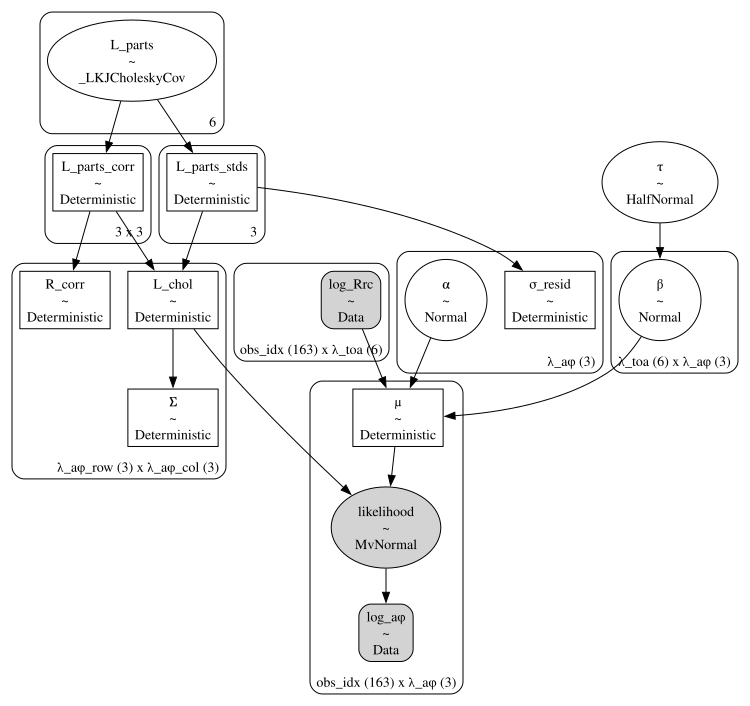

In [248]:
g = m_lin_mvn.to_graphviz()
g

In [ ]:
with m_lin_mvn:
    idata_lin_mvn = pm.sample_prior_predictive()
    idata_lin_mvn.extend(
        pm.sample(
            chains=4, tune=2500, draws=2000, init="jitter+adapt_diag", 
            nuts_sampler_kwargs=dict(target_accept=0.95, max_treedepth=15)))
    pm.sample_posterior_predictive(idata_lin_mvn, extend_inferencedata=True)
    pm.compute_log_likelihood(idata_lin_mvn, extend_inferencedata=True, )

Sampling: [L_parts, likelihood, α, β, τ]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [τ, α, β, L_parts]


Output()

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/pytensor/compile/function/types.py:992: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/pytensor/compile/function/types.py:992: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 2579 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [250]:
with m_lin_mvn:
    pm.sample_posterior_predictive(idata_lin_mvn, extend_inferencedata=True)
    pm.compute_log_likelihood(idata_lin_mvn, extend_inferencedata=True)

Sampling: [likelihood]


Output()

Output()

In [ ]:
save_idata(idata_lin_mvn, DIR["idata"], "linear_mvn")

PosixPath('/Users/erdemkarakoylu/projex/bayesian_toa_2_iop/inferencedata/lin_mvn.nc')

In [266]:
az.summary(idata_lin_mvn, kind='diagnostics').round(3)

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/diagnostics.p

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α[443],0.005,0.002,1108.0,2169.0,1.0
α[555],0.008,0.004,1162.0,2142.0,1.0
α[670],0.006,0.003,1160.0,2144.0,1.0
"β[412, 443]",0.032,0.014,523.0,1132.0,1.0
"β[412, 555]",0.043,0.021,610.0,1210.0,1.0
...,...,...,...,...,...
"R_corr[670, 555]",0.001,0.000,1622.0,3046.0,1.0
"R_corr[670, 670]",0.000,0.000,8034.0,8000.0,1.0
σ_resid[443],0.000,0.000,933.0,2026.0,1.0
σ_resid[555],0.001,0.000,1178.0,2214.0,1.0


<Axes: >

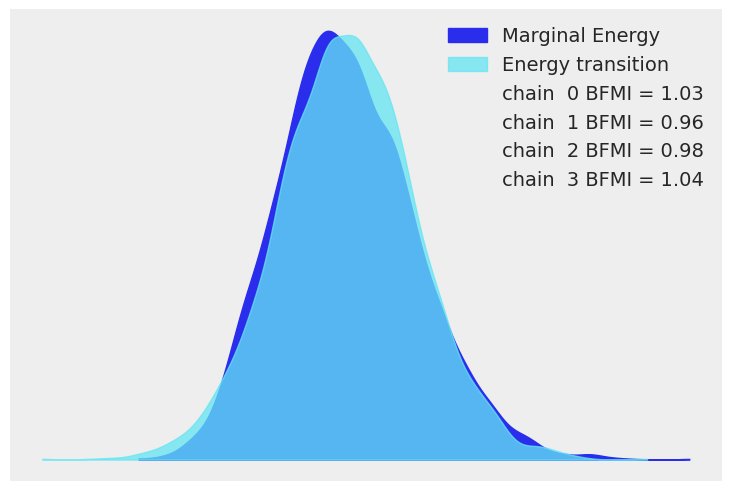

In [318]:
az.plot_energy(idata_lin_mvn)

<Axes: xlabel='likelihood'>

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


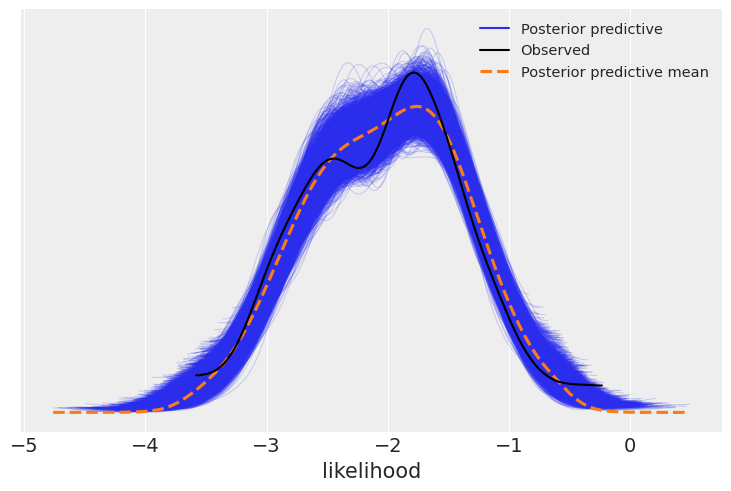

In [317]:
az.plot_ppc(idata_lin_mvn)

In [339]:
idata_lin_mvn

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

In [386]:
def compute_psislw(idata, obs_dim='obs_idx', like_var="likelihood"):
    # joint PSIS log-weights (obs x draws)
    ll = idata.log_likelihood[like_var]  # (chain, draw, obs)
    lw = ll.stack(sample=("chain","draw")).transpose(obs_dim, "sample").values
    logw, khat = az.psislw(lw)
    return logw

def az_loo_pit_per_band(idata, like_var="likelihood", obs_dim="obs_idx", band_dim="λ_aφ",
                        ecdf=True, hdi_prob=0.94):
    lw = compute_psislw(idata, obs_dim=obs_dim, like_var=like_var)
    bands = idata.posterior_predictive[like_var].coords[band_dim].values
    n = len(bands)
    fig = pp.figure(figsize=(4*n, 3))
    axes = []
    for i, b in enumerate(bands):
        y = idata.observed_data[like_var].sel({band_dim: b}).values
        yhat = (
            idata.posterior_predictive[like_var]
            .sel({band_dim: b})
            .stack(sample=("chain", "draw"))
            .transpose(obs_dim, "sample")
            .values)
        ax = fig.add_subplot(1, 3, i+1)
        legend=True if i<=0 else False
        ax = az.plot_loo_pit(y=y, y_hat=yhat, log_weights=lw, legend=legend, ecdf=ecdf, ax=ax, hdi_prob=hdi_prob)
        ax.set_ylabel('ECDF')
        ax.set_xlabel(r"$PIT(y_i|y_{-i})$")
        ax.set_title(f"LOO-PIT - AΦ({b})")
        axes.append(ax)

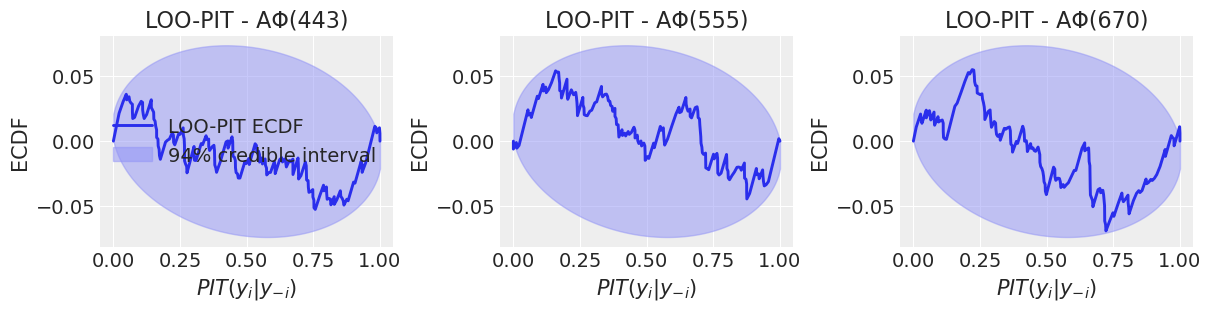

In [387]:
az_loo_pit_per_band(idata_lin_mvn)

In [ ]:
def _get_ll_and_logw(idata, like_var="likelihood", obs_dim="obs_idx", band_dim="λ_aφ"):
    """Return (ll_obs, logw_obs) where ll_obs has shape (obs,) and logw_obs (obs, draws).
       Works whether idata.log_likelihood[like_var] is (obs) or (obs, band)."""
    ll_da = idata.log_likelihood[like_var]                        # dims: (chain, draw, obs[, band]?)
    ll_obs = ll_da
    # If per-band ll is present, reduce to per-obs by summing bands (log joint over bands)
    if band_dim in ll_da.dims:
        ll_obs = ll_da.sum(dim=band_dim)
    ll_obs = ll_obs.stack(sample=("chain","draw")).transpose(obs_dim, "sample")  # (obs, draws)
    logw, _ = az.psislw(ll_obs.values)                                          # PSIS per obs
    return ll_obs, logw

def loo_pit_per_band(idata, like_var="likelihood",
                     obs_dim="obs_idx", band_dim="λ_aφ",
                     ecdf=True, hdi_prob=0.94, figsize_scale=3.2):
    """Faceted LOO-PIT: one panel per band. Works for MVN and non-MVN."""
    _, logw_obs = _get_ll_and_logw(idata, like_var, obs_dim, band_dim)
    bands = list(idata.posterior_predictive[like_var].coords[band_dim].values)
    n = len(bands)
    fig, axes = pp.subplots(1, n, figsize=(figsize_scale*n, figsize_scale), squeeze=False)
    axes = axes[0]

    for ax, b in zip(axes, bands):
        y = idata.observed_data[like_var].sel({band_dim: b}).values
        yhat = (idata.posterior_predictive[like_var]
                .sel({band_dim: b})
                .stack(sample=("chain","draw"))
                .transpose(obs_dim, "sample")
                .values)                                         # (obs, draws)
        # Use the obs-level PSIS weights for each band
        y_da = xr.DataArray(y, dims=[obs_dim], name=f"{like_var}_{b}")
        az.plot_loo_pit(y=y_da, y_hat=yhat, log_weights=logw_obs,
                        ecdf=ecdf, hdi_prob=hdi_prob, legend=(b==bands[0]), ax=ax)
        ax.set_xlabel(r"$PIT(y_i \mid y_{-i})$")
        ax.set_ylabel("ECDF" if ecdf else "Density")
        ax.set_title(f"LOO-PIT — aph({b})")
    fig.tight_layout()
    return fig, axes

def loo_pit_all_bands_one_panel(idata, like_var="likelihood",
                                obs_dim="obs_idx", band_dim="λ_aφ",
                                ecdf=False, hdi_prob=0.94, ax=None):
    """Single LOO-PIT combining all bands. Works for MVN and non-MVN."""
    ll_obs, logw_obs = _get_ll_and_logw(idata, like_var, obs_dim, band_dim)

    # Stack bands into obs for y and yhat
    y_all = (idata.observed_data[like_var]
             .stack(obs=(obs_dim, band_dim))
             .values)                                           # (obs*band,)
    yhat_all = (idata.posterior_predictive[like_var]
                .stack(obs=(obs_dim, band_dim))
                .stack(sample=("chain","draw"))
                .transpose("obs","sample")
                .values)                                        # (obs*band, draws)

    # Tile PSIS weights across bands so shapes match
    n_bands = idata.observed_data[like_var].sizes[band_dim]
    logw_tiled = np.repeat(logw_obs, n_bands, axis=0)           # (obs*band, draws)

    y_da = xr.DataArray(y_all, dims=["obs"], name=f"{like_var}_allbands")
    ax = az.plot_loo_pit(y=y_da, y_hat=yhat_all, log_weights=logw_tiled,
                         ecdf=ecdf, hdi_prob=hdi_prob, legend=True, ax=ax)
    ax.set_xlabel(r"$PIT(y_i \mid y_{-i})$")
    ax.set_ylabel("ECDF" if ecdf else "Density")
    ax.set_title("LOO-PIT (all bands stacked)" + (" — ECDF deviation" if ecdf else " — KDE vs uniform"))
    return ax


In [ ]:
def _get_ll_and_logw(idata, like_var="likelihood", obs_dim="obs_idx", band_dim="λ_aφ"):
    """Return (ll_obs_da, logw_obs) with shapes:
       ll_obs_da: (obs, draws) as DataArray; logw_obs: (obs, draws) ndarray.
       If LL is per-band, I sum over bands to get joint per-obs LL (standard for PSIS)."""
    ll_da = idata.log_likelihood[like_var]  # dims: (chain, draw, obs[, band]?)
    if band_dim in ll_da.dims:
        ll_da = ll_da.sum(dim=band_dim)
    ll_obs_da = ll_da.stack(sample=("chain","draw")).transpose(obs_dim, "sample")
    logw_obs, _ = az.psislw(ll_obs_da.values)
    return ll_obs_da, logw_obs

def plot_ppc_and_bandwise_pit(
    idata, like_var="likelihood",
    obs_dim="obs_idx", band_dim="λ_aφ",
    hdi_prob=0.94, figsize_scale=3.2
):
    # --- bands & PSIS weights (model-agnostic) ---
    bands = list(idata.posterior_predictive[like_var].coords[band_dim].values)
    _, logw_obs = _get_ll_and_logw(idata, like_var, obs_dim, band_dim)

    # --- layout ---
    n = len(bands)
    fig = pp.figure(figsize=(figsize_scale*n, 2.2*figsize_scale + 2*figsize_scale))
    gs = GridSpec(3, n, figure=fig, height_ratios=[1.4, 1.0, 1.0], hspace=0.35, wspace=0.25)

    # Row 1: PPC spanning all columns
    ax_ppc = fig.add_subplot(gs[0, :])
    ax_ppc.set_title("Posterior Predictive Checks")
    az.plot_ppc(idata, ax=ax_ppc, colors=['darkgray', 'k', 'C1'])
    ax_ppc.set_ylabel("Estimated density")
    ax_ppc.set_xticklabels([])

    # Row 2: KDE-style LOO-PIT per band (ecdf=False)
    for j, b in enumerate(bands):
        ax = fig.add_subplot(gs[1, j])
        y = idata.observed_data[like_var].sel({band_dim: b}).values
        yhat = (idata.posterior_predictive[like_var]
                .sel({band_dim: b})
                .stack(sample=("chain","draw"))
                .transpose(obs_dim, "sample")
                .values)  # (obs, draws)
        y_da = xr.DataArray(y, dims=[obs_dim], name=f"{like_var}_{b}")  # avoid array-as-label
        az.plot_loo_pit(y=y_da, y_hat=yhat, log_weights=logw_obs,
                        ecdf=False, legend=(j==0), ax=ax)
        ax.set_title(f"LOO-PIT KDE — aph({b})")
        ax.set_xlabel(r"$PIT(y_i \mid y_{-i})$")
        if j == 0:
            ax.set_ylabel("Density")

    # Row 3: ECDF deviation per band (ecdf=True)
    for j, b in enumerate(bands):
        ax = fig.add_subplot(gs[2, j])
        y = idata.observed_data[like_var].sel({band_dim: b}).values
        yhat = (idata.posterior_predictive[like_var]
                .sel({band_dim: b})
                .stack(sample=("chain","draw"))
                .transpose(obs_dim, "sample")
                .values)
        y_da = xr.DataArray(y, dims=[obs_dim], name=f"{like_var}_{b}")
        az.plot_loo_pit(y=y_da, y_hat=yhat, log_weights=logw_obs,
                        ecdf=True, hdi_prob=hdi_prob, legend=(j==0), ax=ax)
        ax.set_title(f"LOO-PIT ECDF — aph({b})")
        ax.set_xlabel(r"$PIT(y_i \mid y_{-i})$")
        if j == 0:
            ax.set_ylabel("ECDF deviation")

    fig.tight_layout()
    return fig


/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/3608963920.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/3608963920.py:67: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


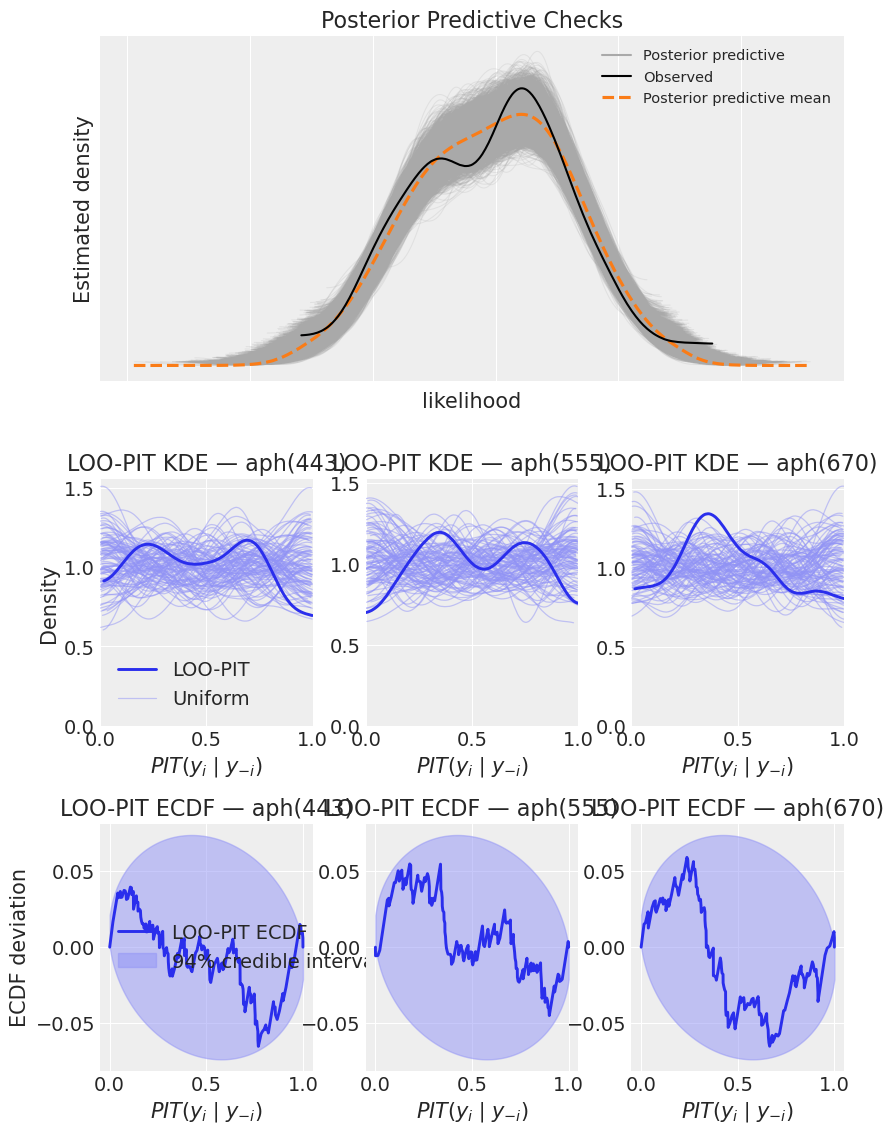

In [394]:
fig_idata_lin = plot_ppc_and_bandwise_pit(idata_lin)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/3608963920.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/3608963920.py:67: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


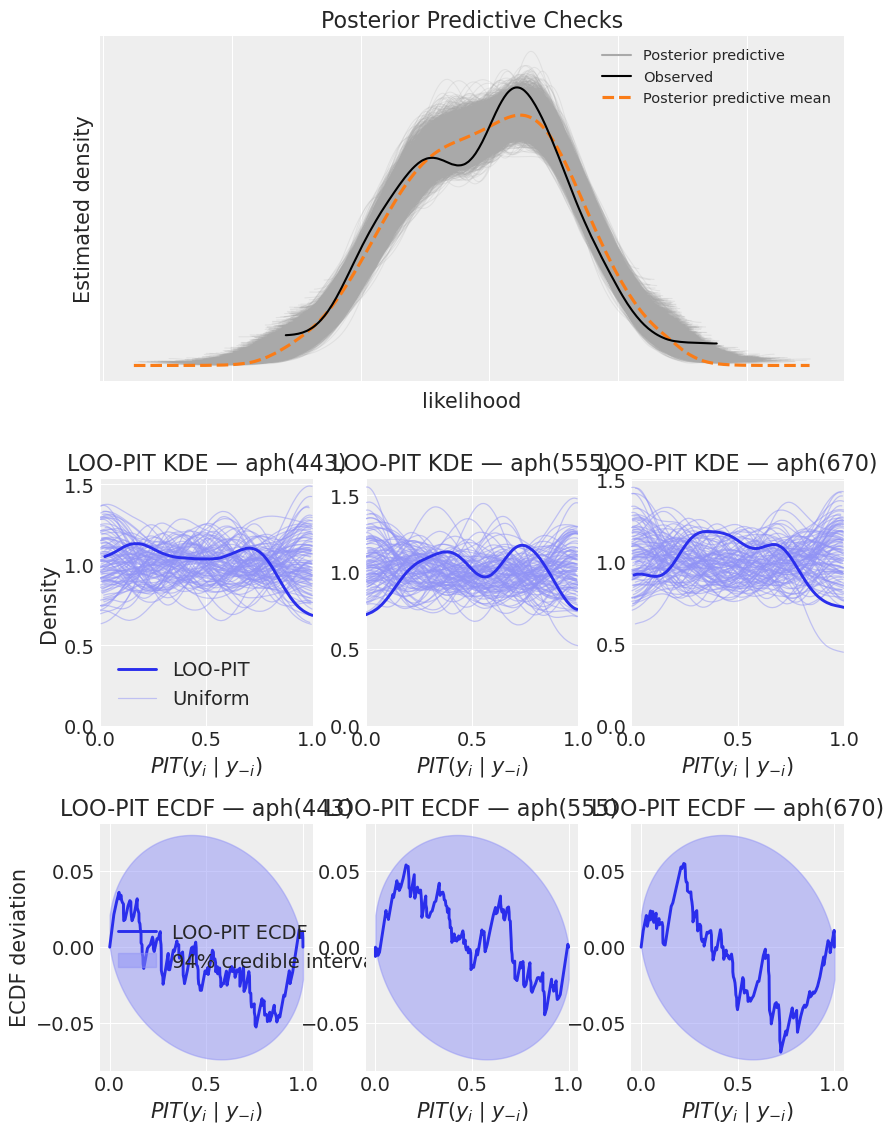

In [395]:
fig_idata_lin_mvn = plot_ppc_and_bandwise_pit(idata_lin_mvn)

In [ ]:
comparison_3 = az.compare(
    dict(
        bart_variant1=idata_bart, 
        model_hier_lin=idata_hier_lin,
        model_vec_hier_lin=idata_vec_centered_beta,
        #model_lin_mvn=idata_lin_mvn 
    ),
    ic='loo', method='BB-pseudo-BMA')

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

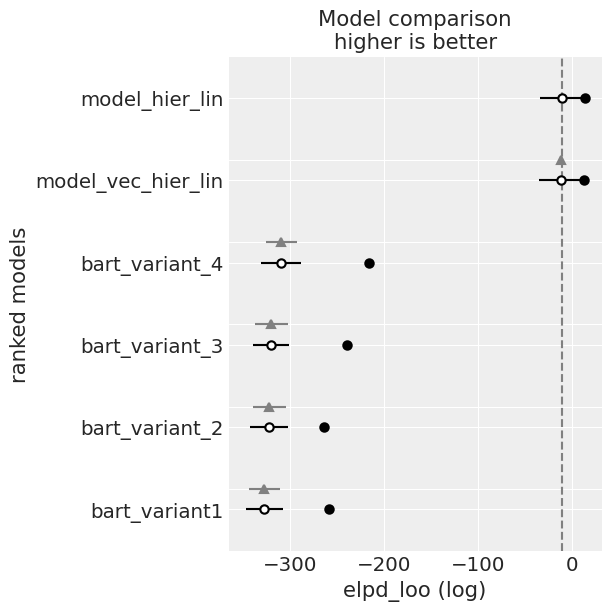

In [313]:
az.plot_compare(comparison_3, plot_ic_diff=True, insample_dev=True)

### Comparing Independent vs Multivariate Models:

#### Problem:
ArviZ is great but one runs into bookkeeping issues when comparing models with different output structures.

* In an MVN model, likelihood ~ MvNormal(mu=μ, chol=L, observed=Y_data) has event shape = K (the bands). ArviZ stores the pointwise log-likelihood with dims (chain, draw, obs_idx) — one value per observation.

* In the independent-Normal model(s), likelihood ~ Normal(..., observed=Y_data, dims=['obs_idx','λ_aφ']) has no event dim; ArviZ stores one log-lik per element with dims (chain, draw, obs_idx, λ_aφ).

### WHy?
Because in PyMC the event dimension is a property of the distribution itself, not something you change by passing dims=.

* pm.MvNormal(...) is vector-valued: it has event_dim = 1 by design. Whatever axis you line up with the vector (your λ_aφ) is treated as the event. Log-probability is summed over that axis internally, so you get one logp per obs_idx. Your dims=['obs_idx','λ_aφ'] just labels axes of the observed array; it does not change the fact that the last axis is an event axis.
* pm.Normal(..., observed=Y, dims=['obs_idx','λ_aφ']) is scalar-valued: it has event_dim = 0. Both axes are treated as batch axes (independent elements). Logp is computed per element, so ArviZ stores (chain, draw, obs_idx, λ_aφ).

#### When the problem arises and symptoms:
When one calls az.compare(ic="loo"), ArviZ expects the same number of pointwise log-likelihood entries across models. Independent and MvN models are N vs N×K, respectively, hence an error will occur.

#### Possible solutions:

For all models to yield one pointwise log-likelihood per observation (to compare with LOO):

1. Either cast the independent model as a diagonal multivariate:

```python
L_diag = pt.diag(σ)  # σ dims 'λ_aφ'
pm.MvNormal('likelihood', mu=μ, chol=L_diag,
            observed=Y_data, dims=['obs_idx','λ_aφ'])
```

2. Or tell PyMC to treat the band axis as an event by wrapping with pm.Independent:

```python
base = pm.Normal.dist(mu=μ, sigma=σ, dims=['obs_idx','λ_aφ'])
pm.Independent('likelihood', base, reinterpreted_batch_ndim=1,
               observed=Y_data, dims=['obs_idx','λ_aφ'])
```

3. Or post-process ArviZ: idata.log_likelihood['likelihood'] = idata.log_likelihood['likelihood'].sum('λ_aφ').

So: dims= assigns names/shape; event vs batch (what gets summed in logp) is determined by the distribution (MvNormal vs Normal) or by explicitly reinterpreting batch dims with pm.Independent.

#### Solution adopted here (avoids refitting models):

One needs to make every model’s pointwise log-likelihood have the same event structure (one value per obs_idx). For any model that stored log_likelihood with an extra band axis (λ_aφ), just sum over that axis. Below is a small, robust helper that:
* checks that log_likelihood exists (and tells you if it doesn’t),
* collapses any extra axes beyond obs_idx (e.g., λ_aφ) so shapes match the MVN,
* returns a new dict ready for az.compare.

In [316]:

def harmonize_idata_ll(idata, obs_dim="obs_idx"):
    """Return a shallow-copied InferenceData whose log_likelihood
    is collapsed to one value per observation (obs_dim)."""
    if not hasattr(idata, "log_likelihood"):
        raise ValueError("InferenceData lacks a log_likelihood group. "
                         "Sample with idata_kwargs={'log_likelihood': True} or compute it first.")

    id_copy = idata.copy()
    # Pick the (only) observed var name in log_likelihood
    ll_vars = list(id_copy.log_likelihood.data_vars)
    if len(ll_vars) != 1:
        # If multiple, pick the first or adapt as needed
        var = ll_vars[0]
    else:
        var = ll_vars[0]

    ll = id_copy.log_likelihood[var]  # e.g., dims: (chain, draw, obs_idx, λ_aφ)
    # Sum over any dims that are not chain/draw/obs_dim
    extra_dims = [d for d in ll.dims if d not in ("chain", "draw", obs_dim)]
    if extra_dims:
        ll = ll.sum(extra_dims)

    # Write back
    id_copy.log_likelihood[var] = ll
    return id_copy

# ---- Harmonize all your models (except MVN which is already per-obs) ----
models_raw = dict(
    #bart_variant1=idata_bart, 
    bart_variant_2=idata_bart_2, 
    bart_variant_3=idata_bart_3,
    bart_variant_4=idata_bart_4,
    model_hier_lin=idata_hier_lin,
    model_vec_hier_lin=idata_vec_centered_beta,
    model_lin_mvn=idata_lin_mvn,              # MVN already per-obs; can include as-is
)

models_harmonized = {}
for name, idata in models_raw.items():
    try:
        models_harmonized[name] = harmonize_idata_ll(idata, obs_dim="obs_idx")
    except ValueError as e:
        print(f"[{name}] {e}")  # reminds you to re-sample with log_likelihood=True or compute it

# If MVN already produces per-obs loglik, you can add it directly:
#models_harmonized["model_lin_mvn"] = idata_lin_mvn

# ---- Compare ----
comparison_3 = az.compare(models_harmonized, ic="loo", method="BB-pseudo-BMA")
comparison_3


/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/erdem

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model_lin_mvn,0,173.496441,29.256730,0.000000,1.000000e+00,28.624579,0.000000,True,log
model_hier_lin,1,-11.192800,24.885168,184.689241,1.539125e-52,32.430822,20.986645,False,log
model_vec_hier_lin,2,-12.050394,24.202623,185.546835,2.595796e-52,32.343676,21.122474,False,log
bart_variant_4,3,-322.311753,112.072827,495.808193,9.622475e-159,35.021753,33.322679,True,log
bart_variant_2,4,-332.742388,73.739459,506.238829,3.035601e-161,33.164063,33.041559,True,log
bart_variant_3,5,-333.455771,100.513477,506.952211,1.550634e-166,31.088827,31.703327,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

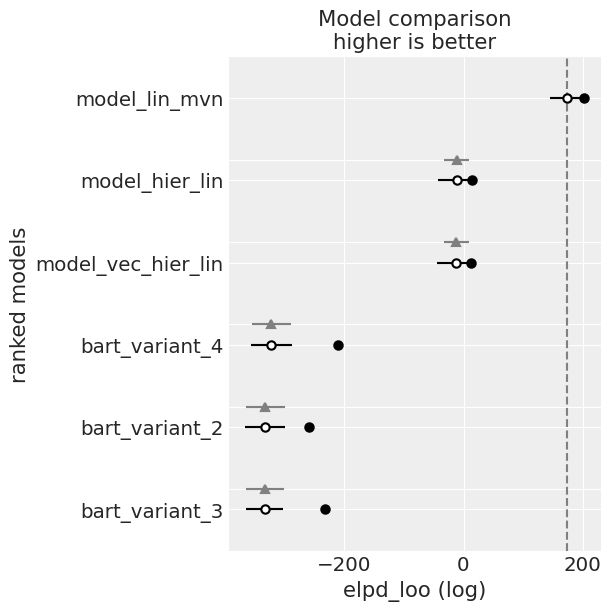

In [321]:
az.plot_compare(comparison_3, plot_ic_diff=True, insample_dev=True)

### Adding a Hierarchical Structure to the MultiVariate Model.

In [333]:
with pm.Model(coords=coords_mvn) as m_hier_lin_mvn: 
    # Data
    X_data = pm.Data('log_Rrc', X.values, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y.values, dims=['obs_idx', 'λ_aφ'])

    # --- Intercepts: (α0 + zero-sum deviations trick (from earlier)
    α0 = pm.Normal('α0', 0, 2) # global intercept
    σ_α = pm.Gamma('σ_α', 2.0, 2.0) # mode=0.5
    α_raw = pm.Normal('α_raw', 0, 1, dims='λ_aφ')
    α_dev = pm.Deterministic('α_dev', α_raw - pt.mean(α_raw, keepdims=True), dims='λ_aφ')
    α = pm.Deterministic('α', α0  + σ_α * α_dev, dims='λ_aφ')

    # --- SLopes: per-predictor shared level + zero-sum devaiations across outputs ---
    β0 = pm.Normal('β0', 0, 0.5, dims='λ_toa') # global slope per predictor
    σ_β = pm.Gamma('σ_β', 2.0, 2.0, dims='λ_toa') # global deviation scale (mode 0.5)
    β_raw = pm.Normal('β_raw', 0, 1, dims=['λ_toa', 'λ_aφ'])

    β_dev = pm.Deterministic(
        'β_dev', β_raw - pt.mean(β_raw, axis=1, keepdims=True), dims=['λ_toa', 'λ_aφ'])
    β = pm.Deterministic('β', β0[:, None] + σ_β [:, None] * β_dev, dims=['λ_toa', 'λ_aφ'])

    # Mean
    μ = pm.Deterministic('μ', α + X_data @ β, dims=['obs_idx', 'λ_aφ'])

    # This is the part that changes.
    #    σ = pm.Exponential('σ', 1, dims='λ_aφ')
    #    likelihood = pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data)
    #  Residual covariance via LKJ prior (Cholesky factorization of covariance matrix)
    _, R_corr, σ_resid = pm.LKJCholeskyCov(
        'L_parts', n=len(λ_aph), eta=2, # weakly informative prior
        sd_dist=pm.HalfNormal.dist(1.0),compute_corr=True )
    L = pm.Deterministic('L_chol', 
                         pt.diag(σ_resid) @ pt.linalg.cholesky(R_corr),
                         dims=('λ_aφ_row', 'λ_aφ_col'))
    Σ = pm.Deterministic('Σ', L @ L.T, dims=('λ_aφ_row', 'λ_aφ_col'))
    pm.Deterministic('R_corr', R_corr, dims=('λ_aφ_row', 'λ_aφ_col'))
    pm.Deterministic('σ_resid', σ_resid, dims='λ_aφ')

    likelihood = pm.MvNormal(
        'likelihood', mu=μ, chol=L,
        observed=Y_data, dims=['obs_idx', 'λ_aφ']
        )

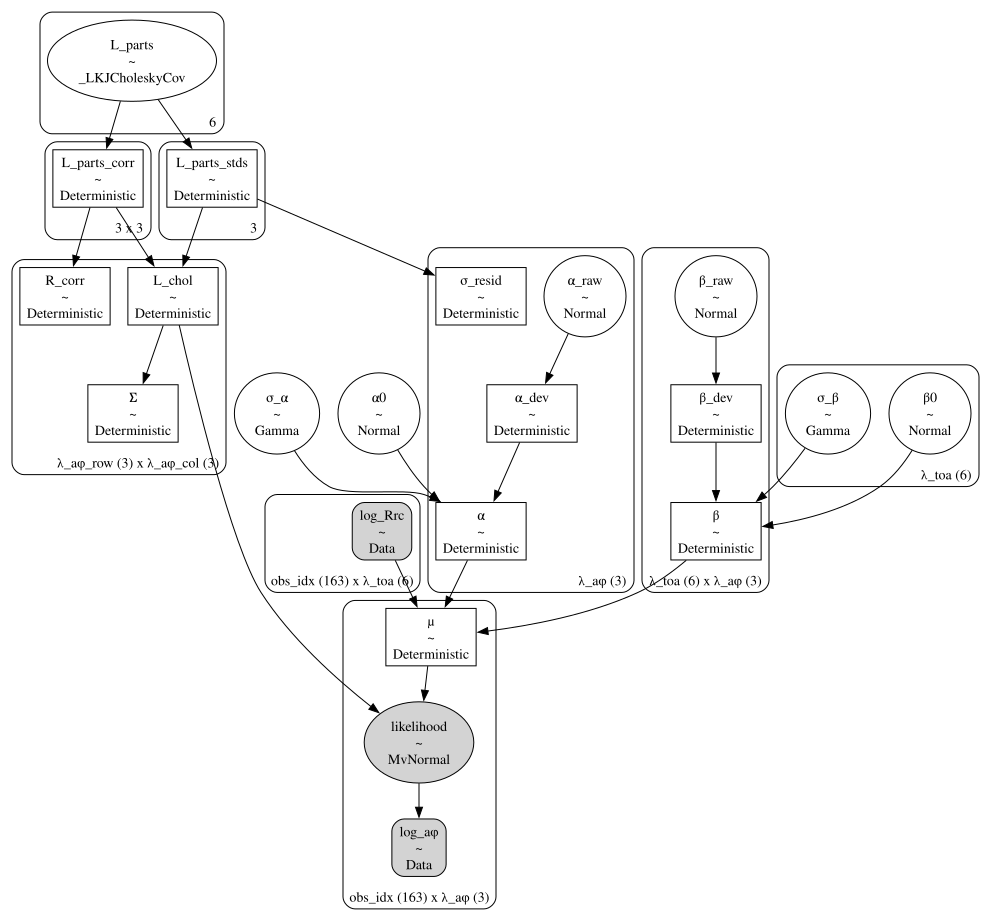

In [334]:
g = m_hier_lin_mvn.to_graphviz()
g

In [335]:
with m_hier_lin_mvn:
    idata_hier_lin_mvn = pm.sample_prior_predictive()
    idata_hier_lin_mvn.extend(
        pm.sample(
            chains=4, tune=2000, draws=2000, init="jitter+adapt_diag", 
            nuts_sampler_kwargs=dict(target_accept=0.99, max_treedepth=15)
            )
        )
    pm.sample_posterior_predictive(idata_hier_lin_mvn, extend_inferencedata=True)
    pm.compute_log_likelihood(idata_hier_lin_mvn, extend_inferencedata=True)

Sampling: [L_parts, likelihood, α0, α_raw, β0, β_raw, σ_α, σ_β]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α0, σ_α, α_raw, β0, σ_β, β_raw, L_parts]


Output()

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/pytensor/compile/function/types.py:992: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/pytensor/compile/function/types.py:992: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/pytensor/compile/function/types.py:992: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4637 seconds.
There were 1052 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [likelihood]


Output()

Output()

In [ ]:
def _get_ll_and_logw(idata, like_var="likelihood", obs_dim="obs_idx", band_dim="λ_aφ"):
    """
    Return (ll_obs_da, logw_obs):
      - ll_obs_da: xarray DataArray of shape (obs, draws) — joint per-observation log-likelihood
      - logw_obs : ndarray of shape (obs, draws) — PSIS log-weights per observation

    If log_likelihood is stored per-band, I sum over bands to get the joint per-observation
    log-likelihood (standard for PSIS-LOO). This makes the function work for MVN and non-MVN.
    """
    ll_da = idata.log_likelihood[like_var]  # dims: (chain, draw, obs[, band]?)
    if "chain" not in ll_da.dims or "draw" not in ll_da.dims:
        raise ValueError(f"{like_var} log_likelihood must contain chain and draw dimensions.")
    # Reduce per-band LL to per-obs LL if needed
    if band_dim in ll_da.dims:
        ll_da = ll_da.sum(dim=band_dim)
    ll_obs_da = ll_da.stack(sample=("chain","draw")).transpose(obs_dim, "sample")  # (obs, draws)
    logw_obs, _ = az.psislw(ll_obs_da.values)
    return ll_obs_da, logw_obs

def plot_ppc_and_bandwise_pit(
    idata,
    like_var="likelihood",
    obs_dim="obs_idx",
    band_dim="λ_aφ",
    ecdf=True,             # True -> ECDF deviation; False -> KDE-style
    hdi_prob=0.94,
    ppc_colors=('darkgray','k','C1'),
    figsize_scale=3.2
):
    """
    Figure with 2 rows x (num bands) columns:
      Row 1: band-wise PPC (one panel per band)
      Row 2: band-wise LOO-PIT (either ECDF deviation OR KDE, controlled by `ecdf`)

    Works for both MVN and non-MVN models (handles log-likelihood shapes internally).
    """
    # Bands present in posterior_predictive
    bands = list(idata.posterior_predictive[like_var].coords[band_dim].values)
    n = len(bands)

    # PSIS weights (per observation) — shared across bands
    _, logw_obs = _get_ll_and_logw(idata, like_var=like_var, obs_dim=obs_dim, band_dim=band_dim)

    # Layout
    fig = pp.figure(figsize=(figsize_scale*n, 2.6*figsize_scale))
    gs = GridSpec(2, n, figure=fig, height_ratios=[1.15, 1.0], hspace=0.35, wspace=0.28)

    # --- Row 1: band-wise PPC
    for j, b in enumerate(bands):
        ax = fig.add_subplot(gs[0, j])
        az.plot_ppc(
            idata,
            var_names=[like_var],
            coords={band_dim: b},
            ax=ax,
            colors=ppc_colors, legend=False
        )
        ax.set_title(f"PPC — aph({b})")
        ax.set_xlabel("")  # hide x-label in row 1
        if j == 0:
            ax.set_ylabel("Estimated density")
        else:
            ax.set_ylabel("")

    # --- Row 2: band-wise LOO-PIT
    for j, b in enumerate(bands):
        ax = fig.add_subplot(gs[1, j])

        # Observed values for band b
        y = idata.observed_data[like_var].sel({band_dim: b}).values
        # Posterior predictive draws for band b, stacked across chains/draws
        yhat = (idata.posterior_predictive[like_var]
                .sel({band_dim: b})
                .stack(sample=("chain","draw"))
                .transpose(obs_dim, "sample")
                .values)  # (obs, draws)

        # Make y an xarray DataArray with a simple name so ArviZ doesn't put long array text on the axis
        y_da = xr.DataArray(y, dims=[obs_dim], name=f"{like_var}_{b}")

        ax = az.plot_loo_pit(
            y=y_da, y_hat=yhat, log_weights=logw_obs,
            ecdf=ecdf, hdi_prob=hdi_prob,
            legend=False, ax=ax
        )
        ax.set_title(f"LOO-PIT — aph({b})" + (" (ECDF)" if ecdf else " (KDE)"))
        ax.set_xlabel(r"$PIT(y_i \mid y_{-i})$")
        if j == 0:
            ax.set_ylabel("ECDF deviation" if ecdf else "Density")
        else:
            ax.set_ylabel("")

    fig.tight_layout()
    return fig

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/577201875.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/577201875.py:93: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


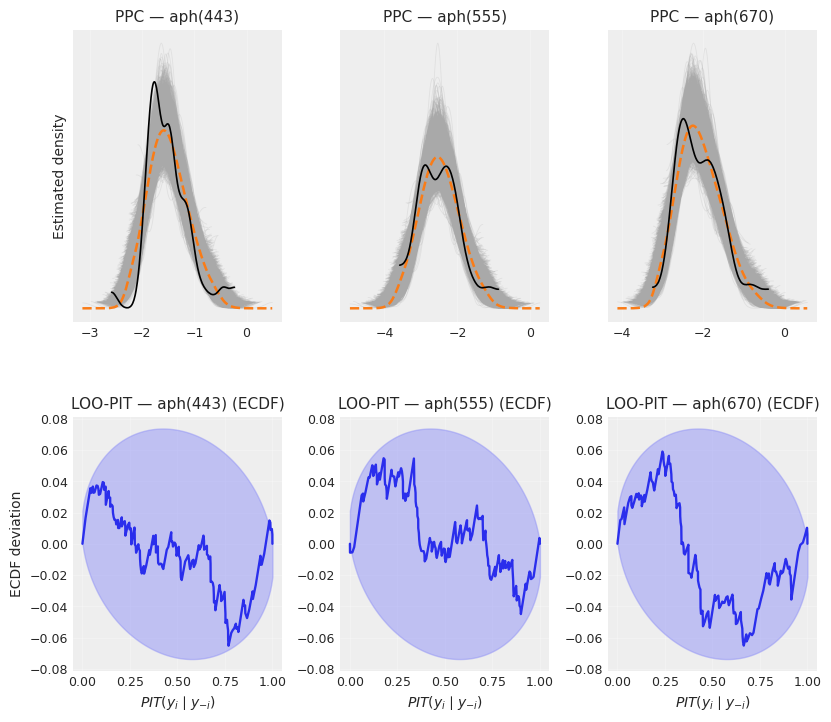

In [407]:
ig = plot_ppc_and_bandwise_pit(
    idata_lin,   # or any of your other idata objects
    like_var="likelihood",
    obs_dim="obs_idx",
    band_dim="λ_aφ",
    ecdf=True,       # switch to False for KDE-style
    hdi_prob=0.94
)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/1408252469.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_90055/1408252469.py:93: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


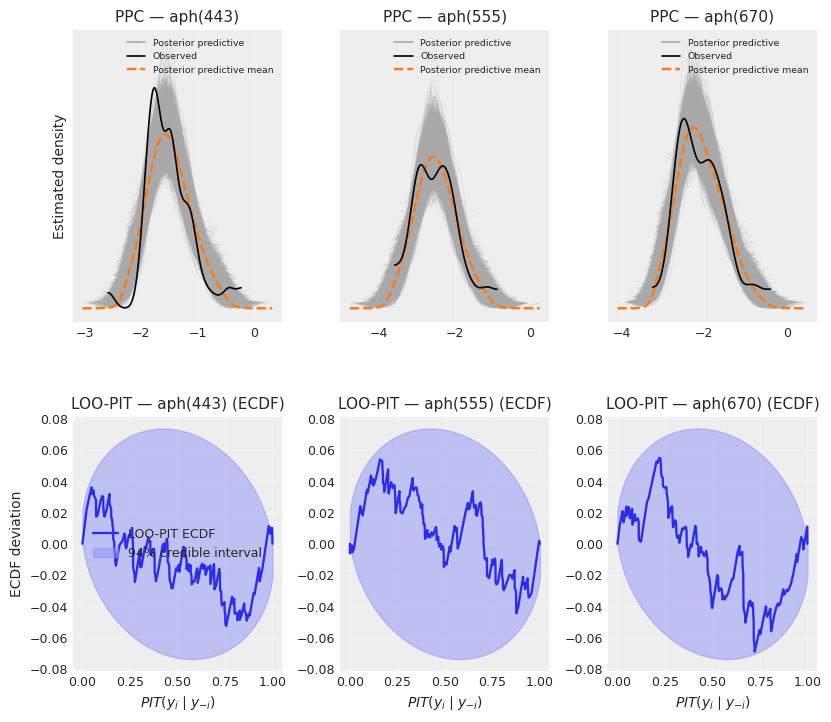

In [405]:
fig = plot_ppc_and_bandwise_pit(
    idata_lin_mvn,   # or any of your other idata objects
    like_var="likelihood",
    obs_dim="obs_idx",
    band_dim="λ_aφ",
    ecdf=True,       # switch to False for KDE-style
    hdi_prob=0.94
)